# Importing the necessary libraries

In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif, mutual_info_regression,f_regression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier ,GradientBoostingRegressor,IsolationForest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso,LinearRegression 
import xgboost as xgb
import matplotlib.ticker as mticker

# loading the file plus feature engineering

In [89]:
# ------------------------------
# 1. Load Data, Drop COVID Anomaly & Engineer Targets
# ------------------------------
df = pd.read_csv('cleaned_new_data.csv')

# Drop COVID anomaly year only (keep 2026 — used as test boundary)
df = df[df['Year'] != 2021].reset_index(drop=True)

repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)
overage_cols = ["pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec"]
df["over_age_enrollment_total"]=df[overage_cols].sum(axis = 1)
# avg_promotion_rate removed — unused downstream
df['kids_population']=df[["pop_aged6_total","pop_aged6_11_total","pop_aged12_14_total","pop_aged15_17_total"]].sum(axis=1)
df['bad_qual_teacher']= df[["teaching_staff_edu_primary","teaching_staff_edu_lower_sec","teaching_staff_edu_upper_sec"]].sum(axis=1)
df['good_qual_teacher']= df[["teaching_staff_edu_graduate","teaching_staff_edu_postgrad","teaching_staff_edu_phd"]].sum(axis=1)
# avg_promotion_rate removed — unused downstream


In [90]:
# ------------------------------
# 2. Staff Qualification Feature Engineering
# ------------------------------
edu_levels = ["primary", "lower_sec", "upper_sec", "graduate", "postgrad", "phd"]
weights = {"primary": 1, "lower_sec": 2, "upper_sec": 3, "graduate": 4, "postgrad": 5, "phd": 6}

# No-pedagogy ratio
df["no_pedagogy_ratio"] = (
    df[[f"teaching_staff_no_pedagogy_{l}" for l in edu_levels]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# High/low qual ratio (teaching staff)
df["teaching_high_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["graduate", "postgrad", "phd"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)
df["teaching_low_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["primary", "lower_sec", "upper_sec"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# Qualification index per staff group
for prefix in ["teaching_staff_edu", "non_teaching_staff_edu", "teaching_staff_no_pedagogy"]:
    weighted_sum = sum(df[f"{prefix}_{level}"] * w for level, w in weights.items())
    total = df[[f"{prefix}_{level}" for level in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f"{prefix}_qual_index"] = weighted_sum / total


In [91]:
print(df.shape)
print(df[['Year','enrollment_total']].groupby('Year').mean())

(250, 275)
      enrollment_total
Year                  
2016         120385.44
2017         123106.40
2018         125730.08
2019         127566.88
2020         128411.40
2022         130631.08
2023         133770.48
2024         136326.16
2025         136928.20
2026         128292.92


count       250.000000
mean     129114.904000
std       84816.406568
min        8162.000000
25%       51697.000000
50%      123149.500000
75%      206739.750000
max      285422.000000
Name: enrollment_total, dtype: float64
Axes(0.125,0.11;0.775x0.77)


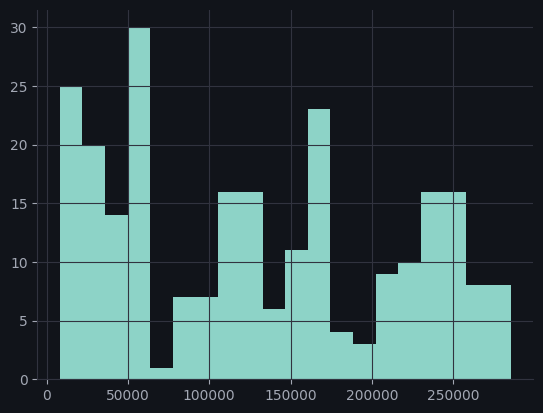

In [92]:
print(df['enrollment_total'].describe())
print(df['enrollment_total'].hist(bins=20))

In [93]:
print(df.shape)
print(df[['Year','avg_dropout_rate']].groupby('Year').mean())

(250, 275)
      avg_dropout_rate
Year                  
2016         14.182333
2017         11.764667
2018         10.903143
2019         10.799647
2020         13.246976
2022         13.512436
2023         12.585495
2024         10.700333
2025          9.753000
2026          9.171333


count    250.000000
mean      11.661936
std        2.535054
min        6.491667
25%        9.827083
50%       11.454167
75%       13.250640
max       21.433333
Name: avg_dropout_rate, dtype: float64
Axes(0.125,0.11;0.775x0.77)


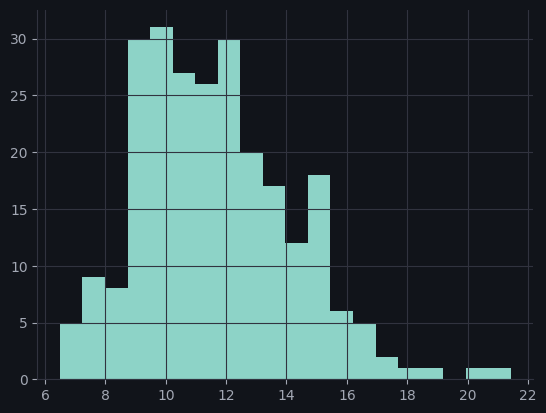

In [94]:
print(df['avg_dropout_rate'].describe())
print(df['avg_dropout_rate'].hist(bins=20))

In [95]:
print(df.shape)
print(df[['Year','teaching_staff_edu_qual_index']].groupby('Year').mean())

(250, 275)
      teaching_staff_edu_qual_index
Year                               
2016                       2.886743
2017                       2.935811
2018                       2.960639
2019                       3.010407
2020                       3.017466
2022                       3.099015
2023                       3.158603
2024                       3.189569
2025                       3.211495
2026                       3.285969


count    250.000000
mean       3.075572
std        0.205065
min        2.424284
25%        2.947118
50%        3.089394
75%        3.225114
max        3.523707
Name: teaching_staff_edu_qual_index, dtype: float64
Axes(0.125,0.11;0.775x0.77)


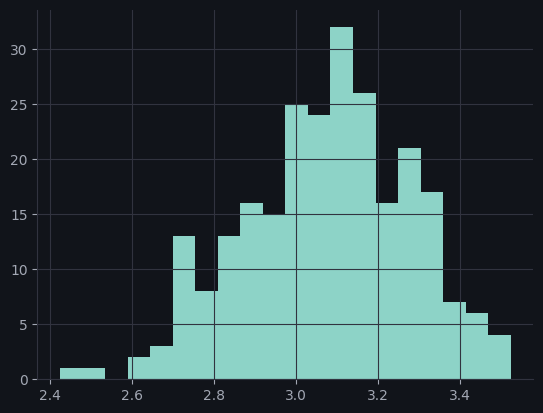

In [96]:
print(df['teaching_staff_edu_qual_index'].describe())
print(df['teaching_staff_edu_qual_index'].hist(bins=20))

In [97]:
def remove_outliers_iforest(df, contamination=0.05):
    numeric_df = df.select_dtypes(include=["number"]).dropna()

    iso = IsolationForest(contamination=contamination, random_state=42)
    preds = iso.fit_predict(numeric_df)

    valid_indices = numeric_df.index[preds == 1]
    yeeted_indices = numeric_df.index[preds == -1]

    print(f"=== YEETED {len(yeeted_indices)} ROWS VIA ISOLATION FOREST ===")
    if not yeeted_indices.empty:
        with pd.option_context(
            "display.max_columns", None, "display.width", 1000
        ):
            print(df.loc[yeeted_indices])
    print("==================================================\n")

    return df.loc[valid_indices].copy()

In [98]:
remove_outliers_iforest(df)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
     row_id  Year    Province  num_schools  num_classes  classes_in_pagoda  enrollment_total  enrollment_girl  repeaters_total  repeaters_girl  teaching_staff_total  teaching_staff_female  non_teaching_staff_total  non_teaching_staff_female  total_staff_total  total_staff_female  num_schools_preschool  num_schools_primary  num_schools_college  num_schools_lycee  two_shift_schools_lycee  floating_schools_lycee  schools_in_pagoda_lycee  attached_preschool_lycee  schools_without_water  schools_without_latrine  principal_avg_age  principal_avg_service_years  principal_upper_sec_plus_edu  principal_female  num_primary_schools  num_cluster_schools  satellite_schools  satellite_classes  pagoda_preschool_schools  pagoda_preschool_classes  pagoda_primary_schools  pagoda_primary_classes  pagoda_junior_high_schools  pagoda_junior_high_classes  pagoda_senior_high_schools  pagoda_senior_high_classes  g1_enrollment_total  g1_enrollment_girl  g1_repeaters_t

,row_id,Year,Province,num_schools,num_classes,classes_in_pagoda,enrollment_total,enrollment_girl,repeaters_total,repeaters_girl,...,over_age_enrollment_total,kids_population,bad_qual_teacher,good_qual_teacher,no_pedagogy_ratio,teaching_high_qual_ratio,teaching_low_qual_ratio,teaching_staff_edu_qual_index,non_teaching_staff_edu_qual_index,teaching_staff_no_pedagogy_qual_index
0,0,2016,Banteay Meanchey,774.0,4276.0,21.0,139995.0,69636.0,4534.0,1679.0,...,52.2,223767.0,3806.0,829.0,0.008846,0.178857,0.821143,2.970011,2.904813,3.536585
1,1,2016,Battambang,1044.0,6995.0,20.0,233906.0,115311.0,11614.0,4490.0,...,69.0,346260.0,5350.0,1414.0,0.011088,0.209048,0.790952,2.957422,2.879169,2.826667
2,2,2016,Kampong Cham,757.0,5544.0,108.0,212068.0,105172.0,14465.0,5451.0,...,60.3,280491.0,4954.0,622.0,0.011298,0.111549,0.888451,2.713415,2.647601,2.714286
3,3,2016,Kampong Chhnang,447.0,3093.0,14.0,112868.0,56749.0,5800.0,2125.0,...,59.2,160828.0,2814.0,569.0,0.005025,0.168194,0.831806,2.953000,2.867200,3.882353
4,4,2016,Kampong Speu,562.0,4017.0,33.0,165118.0,80487.0,7053.0,2817.0,...,62.6,244817.0,3358.0,912.0,0.034192,0.213583,0.786417,2.939110,2.877019,3.191781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,269,2026,Ratanak Kiri,272.0,1808.0,15.0,54497.0,26846.0,2206.0,809.0,...,78.2,68488.0,1066.0,394.0,0.025342,0.269863,0.730137,3.110274,3.275862,3.594595
246,271,2026,Stung Treng,216.0,1804.0,0.0,41950.0,20963.0,2744.0,994.0,...,66.0,51426.0,1073.0,353.0,0.019635,0.247546,0.752454,3.035063,2.919679,2.535714
247,272,2026,Svay Rieng,344.0,3025.0,17.0,122012.0,60499.0,3564.0,1040.0,...,35.0,142128.0,1976.0,1637.0,0.010794,0.453086,0.546914,3.347910,3.251755,3.794872
248,273,2026,Takeo,513.0,5110.0,74.0,194388.0,96382.0,7009.0,2226.0,...,40.2,225689.0,3096.0,2935.0,0.011441,0.486652,0.513348,3.384348,3.283453,3.84058


# feature selection and model training

In [99]:

features_for_enrollment = [
    "num_schools", "classes_in_pagoda", "repeaters_total", "total_staff_total",
    "two_shift_schools_lycee", "floating_schools_lycee", "schools_in_pagoda_lycee", "attached_preschool_lycee",
    "schools_without_water", "schools_without_latrine", "principal_avg_age", "principal_avg_service_years",
    "principal_upper_sec_plus_edu", "principal_female", "num_primary_schools", "num_cluster_schools",
    "satellite_schools", "num_buildings_total", "num_rooms_total", "concrete_brick_buildings",
    "wooden_buildings", "bamboo_buildings", "buildings_repaired", "buildings_constructed",
    "buildings_poor_floor", "buildings_poor_roof", "buildings_poor_wall", "schools_with_office",
    "schools_with_library", "school_area_land_m2", "school_area_playground_m2", "classroom_area_per_student",
    "preschool_with_sport_facility", "sport_volleyball", "sport_football", "sport_basketball",
    "sport_climbing_ropes", "sport_shotput", "sport_high_jump", "sport_long_jump", "sport_running",
    "pb_fund_per_student_riel", "pb_fund_per_school_riel", "funding_school_income", "funding_community",
    "funding_govt_building", "funding_abroad", "funding_ios_ngos", "pupils_per_school", "teachers_per_school",
    "staff_per_school", "buildings_per_school", "rooms_per_school", "classrooms_per_school",
    "classes_per_school", "pupil_teacher_ratio", "pupil_staff_ratio", "pupil_class_ratio",
    "pupil_classroom_ratio", "classes_per_classroom", "classroom_area_per_pupil_m2", "gross_admission_rate_total",
    "net_admission_rate_total", "pct_overage_admission_total", "transition_rate_lower_sec_total",
    "transition_rate_upper_sec_total",
    "no_pedagogy_ratio", "teaching_high_qual_ratio",
    "teaching_low_qual_ratio", "teaching_staff_edu_qual_index",
    "non_teaching_staff_edu_qual_index", "teaching_staff_no_pedagogy_qual_index"
]
features_for_dropout = [
    "num_schools", "classes_in_pagoda","repeaters_total","total_staff_total",
    "two_shift_schools_lycee", "floating_schools_lycee", "schools_in_pagoda_lycee", "attached_preschool_lycee","schools_without_water", "schools_without_latrine",
    "principal_avg_age", "principal_avg_service_years", "principal_upper_sec_plus_edu", "principal_female",
    "num_primary_schools", "num_cluster_schools", "satellite_schools",
    "num_buildings_total", "num_rooms_total",
    "concrete_brick_buildings","wooden_buildings","bamboo_buildings",
    "buildings_repaired", "buildings_constructed",
    "buildings_poor_floor", "buildings_poor_roof", "buildings_poor_wall","over_age_enrollment_total",
    "schools_with_office", "schools_with_library",
    "school_area_land_m2", "school_area_playground_m2", "classroom_area_per_student",
    "pb_fund_per_student_riel", "pb_fund_per_school_riel",
    "funding_school_income", "funding_community", "funding_govt_building", "funding_abroad", "funding_ios_ngos",
    "pupils_per_school", "teachers_per_school", "staff_per_school",
    "buildings_per_school", "rooms_per_school", "classrooms_per_school", "classes_per_school",
    "pupil_teacher_ratio", "pupil_staff_ratio", "pupil_class_ratio", "pupil_classroom_ratio",
    "classes_per_classroom", "classroom_area_per_pupil_m2",
    "gross_admission_rate_total","net_admission_rate_total","transition_rate_lower_sec_total","transition_rate_upper_sec_total",
    "no_pedagogy_ratio", "teaching_high_qual_ratio",
    "teaching_low_qual_ratio", "teaching_staff_edu_qual_index",
    "non_teaching_staff_edu_qual_index", "teaching_staff_no_pedagogy_qual_index"
]
features_for_teacher = [
    "num_schools", "classes_in_pagoda", "repeaters_total",
    "two_shift_schools_lycee", "floating_schools_lycee", "schools_in_pagoda_lycee", "attached_preschool_lycee",
    "schools_without_water", "schools_without_latrine", "principal_avg_age", "principal_avg_service_years",
    "principal_upper_sec_plus_edu", "principal_female", "num_primary_schools", "num_cluster_schools",
    "satellite_schools", "num_buildings_total", "num_rooms_total", "concrete_brick_buildings",
    "wooden_buildings", "bamboo_buildings", "buildings_repaired", "buildings_constructed",
    "buildings_poor_floor", "buildings_poor_roof", "buildings_poor_wall", "schools_with_office",
    "schools_with_library", "school_area_land_m2", "school_area_playground_m2", "classroom_area_per_student",
    "preschool_with_sport_facility", "sport_volleyball", "sport_football", "sport_basketball",
    "sport_climbing_ropes", "sport_shotput", "sport_high_jump", "sport_long_jump", "sport_running",
    "pb_fund_per_student_riel", "pb_fund_per_school_riel", "funding_school_income", "funding_community",
    "funding_govt_building", "funding_abroad", "funding_ios_ngos", "pupils_per_school", "teachers_per_school",
    "staff_per_school", "buildings_per_school", "rooms_per_school", "classrooms_per_school",
    "classes_per_school", "pupil_teacher_ratio", "pupil_staff_ratio", "pupil_class_ratio",
    "pupil_classroom_ratio", "classes_per_classroom", "classroom_area_per_pupil_m2", "gross_admission_rate_total",
    "net_admission_rate_total", "pct_overage_admission_total", "transition_rate_lower_sec_total",
    "transition_rate_upper_sec_total", "avg_repetition_rate", "avg_dropout_rate",
]

In [100]:
def select_features(df, target_col, features_all, k_num=10, classification=False, log_transform=False):
    """
    Perform 3 feature selection methods on a dataset, including union and intersection strategies.
    """
    y = df[target_col].copy()
    
    # Apply log transform BEFORE feature selection if specified
    if log_transform:
        y = np.log1p(y)  # log1p handles 0 values safely
    
    if classification:
        y = pd.qcut(y, q=3, labels=["low", "medium", "high"], duplicates='drop')

    # Only keep features that exist in the dataframe
    valid_features = [f for f in features_all if f in df.columns]
    X = df[valid_features].copy()

    # FIX: impute before any sklearn method
    X = X.fillna(np.nan)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    results = {}

    # Method 1: ANOVA F-test
    score_fn_anova = f_classif if classification else f_regression
    anova_sel = SelectKBest(score_func=score_fn_anova, k=k_num).fit(X_imp, y)
    results['anova'] = list(X_imp.columns[anova_sel.get_support()])

    # Method 2: Mutual Information
    mi_fn = mutual_info_classif if classification else mutual_info_regression
    mi_sel = SelectKBest(score_func=mi_fn, k=k_num).fit(X_imp, y)
    results['mutual_info'] = list(X_imp.columns[mi_sel.get_support()])

    # Method 3: RFE
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1) if classification else RandomForestRegressor(random_state=42, n_jobs=-1)
    rfe_sel = RFE(estimator=estimator, n_features_to_select=k_num, step=2)
    rfe_sel.fit(X_imp, y)
    results['rfe'] = list(X_imp.columns[rfe_sel.support_])

    # STRATEGY: Intersection
    common = sorted(set(results['anova']) & set(results['mutual_info']) & set(results['rfe']))
    results['common_features'] = common

    # STRATEGY: Union
    union = sorted(set(results['anova']) | set(results['mutual_info']) | set(results['rfe']))
    results['union_features'] = union
    
    results['X_pure'] = X_imp
    results['y'] = y

    return results
    """
    Perform 3 feature selection methods on a dataset, including union and intersection strategies.
    """
    y = df[target_col].copy()
    if classification:
        y = pd.qcut(y, q=3, labels=["low", "medium", "high"], duplicates='drop')

    # Only keep features that exist in the dataframe
    valid_features = [f for f in features_all if f in df.columns]
    X = df[valid_features].copy()

    # FIX: impute before any sklearn method — all 3 fail on NaN
    X = X.fillna(np.nan)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    results = {}

    # Method 1: ANOVA F-test (FIXED: Uses f_regression if classification=False)
    score_fn_anova = f_classif if classification else f_regression
    anova_sel = SelectKBest(score_func=score_fn_anova, k=k_num).fit(X_imp, y)
    results['anova'] = list(X_imp.columns[anova_sel.get_support()])

    # Method 2: Mutual Information
    mi_fn = mutual_info_classif if classification else mutual_info_regression
    mi_sel = SelectKBest(score_func=mi_fn, k=k_num).fit(X_imp, y)
    results['mutual_info'] = list(X_imp.columns[mi_sel.get_support()])

    # Method 3: RFE
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1) if classification else RandomForestRegressor(random_state=42, n_jobs=-1)
    rfe_sel = RFE(estimator=estimator, n_features_to_select=k_num, step=2)
    rfe_sel.fit(X_imp, y)
    results['rfe'] = list(X_imp.columns[rfe_sel.support_])

    # STRATEGY: Intersection (Common features)
    common = sorted(set(results['anova']) & set(results['mutual_info']) & set(results['rfe']))
    results['common_features'] = common

    # STRATEGY: Union (Combined unique features from all methods)
    union = sorted(set(results['anova']) | set(results['mutual_info']) | set(results['rfe']))
    results['union_features'] = union
    
    results['X_pure'] = X_imp
    results['y'] = y

    return results


# ------------------------------
# 5. Tournament Strategy Function
# ------------------------------
def run_feature_tournament(fs_results, classification=False):
    """
    Evaluates all feature subsets via cross-validation to find the highest performing group.
    """
    X = fs_results['X_pure']
    y = fs_results['y']
    
    # Define tournament subsets
    subsets = {
        'ANOVA Subset': fs_results['anova'],
        'Mutual Info Subset': fs_results['mutual_info'],
        'RFE Subset': fs_results['rfe'],
        'Union Strategy (Combined All Unique)': fs_results['union_features'],
        'Intersection Strategy (Common Only)': fs_results['common_features']
    }
    
    # Pick baseline evaluator model based on task type
    model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
    metric = 'accuracy' if classification else 'r2'
    
    print(f"--- Running Feature Tournament (Metric: {metric.upper()}) ---")
    
    tournament_scores = {}
    for name, features in subsets.items():
        if len(features) == 0:
            print(f"🏆 {name}: No features selected. Skipping.")
            continue
            
        # Evaluate subset performance with 5-fold cross-validation
        scores = cross_val_score(model, X[features], y, cv=5, scoring=metric)
        avg_score = np.mean(scores)
        tournament_scores[name] = avg_score
        print(f"⭐ {name} ({len(features)} features) -> Score: {avg_score:.4f}")
        
    winner = max(tournament_scores, key=tournament_scores.get)
    print(f"\n🥇 TOURNAMENT WINNER: {winner} with a score of {tournament_scores[winner]:.4f}")
    return subsets[winner]


# Execution
results = select_features(
    df=df,
    target_col="enrollment_total",
    features_all=features_for_enrollment,
    k_num=10,
    classification=False,
    log_transform=False  
)

print("ANOVA top features:      ", results['anova'])
print("Mutual Info top features:", results['mutual_info'])
print("RFE top features:        ", results['rfe'])
print("Union Strategy features: ", results['union_features'])
print("Common features:         ", results['common_features'])
print("\n")

# Run the tournament strategy to pick the absolute best feature group
best_features = run_feature_tournament(results, classification=False)

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_26400\3212007768.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(np.nan)


ANOVA top features:       ['num_schools', 'repeaters_total', 'total_staff_total', 'two_shift_schools_lycee', 'attached_preschool_lycee', 'num_primary_schools', 'num_cluster_schools', 'satellite_schools', 'num_buildings_total', 'concrete_brick_buildings']
Mutual Info top features: ['num_schools', 'total_staff_total', 'two_shift_schools_lycee', 'attached_preschool_lycee', 'num_primary_schools', 'num_cluster_schools', 'satellite_schools', 'num_buildings_total', 'num_rooms_total', 'concrete_brick_buildings']
RFE top features:         ['repeaters_total', 'total_staff_total', 'two_shift_schools_lycee', 'principal_female', 'num_primary_schools', 'satellite_schools', 'num_buildings_total', 'num_rooms_total', 'concrete_brick_buildings', 'pupil_teacher_ratio']
Union Strategy features:  ['attached_preschool_lycee', 'concrete_brick_buildings', 'num_buildings_total', 'num_cluster_schools', 'num_primary_schools', 'num_rooms_total', 'num_schools', 'principal_female', 'pupil_teacher_ratio', 'repeaters

In [101]:
# --- Run for avg_dropout_rate ---
results = select_features(
    df=df,
    target_col="avg_dropout_rate",
    features_all=features_for_dropout,
    k_num=10,
    classification=False,
    log_transform=True  
)

print("ANOVA top features:      ", results['anova'])
print("Mutual Info top features:", results['mutual_info'])
print("RFE top features:        ", results['rfe'])
print("Union Strategy features: ", results['union_features'])
print("Common features:         ", results['common_features'])
print("\n")

# Run the tournament strategy to pick the absolute best feature group
best_features = run_feature_tournament(results, classification=False)

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_26400\3212007768.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(np.nan)


ANOVA top features:       ['over_age_enrollment_total', 'buildings_per_school', 'classrooms_per_school', 'classes_per_classroom', 'transition_rate_lower_sec_total', 'transition_rate_upper_sec_total', 'teaching_high_qual_ratio', 'teaching_low_qual_ratio', 'teaching_staff_edu_qual_index', 'non_teaching_staff_edu_qual_index']
Mutual Info top features: ['principal_avg_age', 'principal_avg_service_years', 'satellite_schools', 'over_age_enrollment_total', 'pb_fund_per_school_riel', 'buildings_per_school', 'rooms_per_school', 'classes_per_classroom', 'transition_rate_lower_sec_total', 'transition_rate_upper_sec_total']
RFE top features:         ['schools_without_water', 'over_age_enrollment_total', 'pb_fund_per_school_riel', 'funding_abroad', 'staff_per_school', 'buildings_per_school', 'gross_admission_rate_total', 'transition_rate_lower_sec_total', 'transition_rate_upper_sec_total', 'teaching_staff_edu_qual_index']
Union Strategy features:  ['buildings_per_school', 'classes_per_classroom', '

In [102]:
results = select_features(
    df=df,
    target_col="teaching_staff_edu_qual_index",
    features_all=features_for_teacher,
    k_num=10,
    classification=False,
    log_transform=False  
)

print("ANOVA top features:      ", results['anova'])
print("Mutual Info top features:", results['mutual_info'])
print("RFE top features:        ", results['rfe'])
print("Union Strategy features: ", results['union_features'])
print("Common features:         ", results['common_features'])
print("\n")

# Run the tournament strategy to pick the absolute best feature group
best_features = run_feature_tournament(results, classification=False)

ANOVA top features:       ['principal_avg_service_years', 'buildings_poor_floor', 'sport_basketball', 'buildings_per_school', 'classrooms_per_school', 'pupil_class_ratio', 'classes_per_classroom', 'gross_admission_rate_total', 'pct_overage_admission_total', 'transition_rate_lower_sec_total']
Mutual Info top features: ['schools_without_latrine', 'principal_avg_service_years', 'principal_upper_sec_plus_edu', 'num_buildings_total', 'buildings_poor_floor', 'buildings_poor_roof', 'sport_football', 'pb_fund_per_student_riel', 'pb_fund_per_school_riel', 'classrooms_per_school']
RFE top features:         ['schools_without_latrine', 'principal_avg_service_years', 'principal_upper_sec_plus_edu', 'buildings_poor_roof', 'schools_with_office', 'pb_fund_per_student_riel', 'pb_fund_per_school_riel', 'classrooms_per_school', 'gross_admission_rate_total', 'transition_rate_lower_sec_total']
Union Strategy features:  ['buildings_per_school', 'buildings_poor_floor', 'buildings_poor_roof', 'classes_per_cla

>>> ENROLLMENT

  TARGET: enrollment_total
            Model      R²       RMSE        MAE
Gradient Boosting  0.9857 10310.6670  6605.0897
    Random Forest  0.9819 11619.2926  8163.7575
            Lasso  0.9818 11637.5975  8418.6972
            Ridge  0.9818 11637.5974  8418.6972
          XGBoost  0.9790 12497.4955  7681.3289
     SVR (Linear) -0.0182 87113.6144 74338.4045
        SVR (RBF) -0.0183 87117.2056 74279.6109



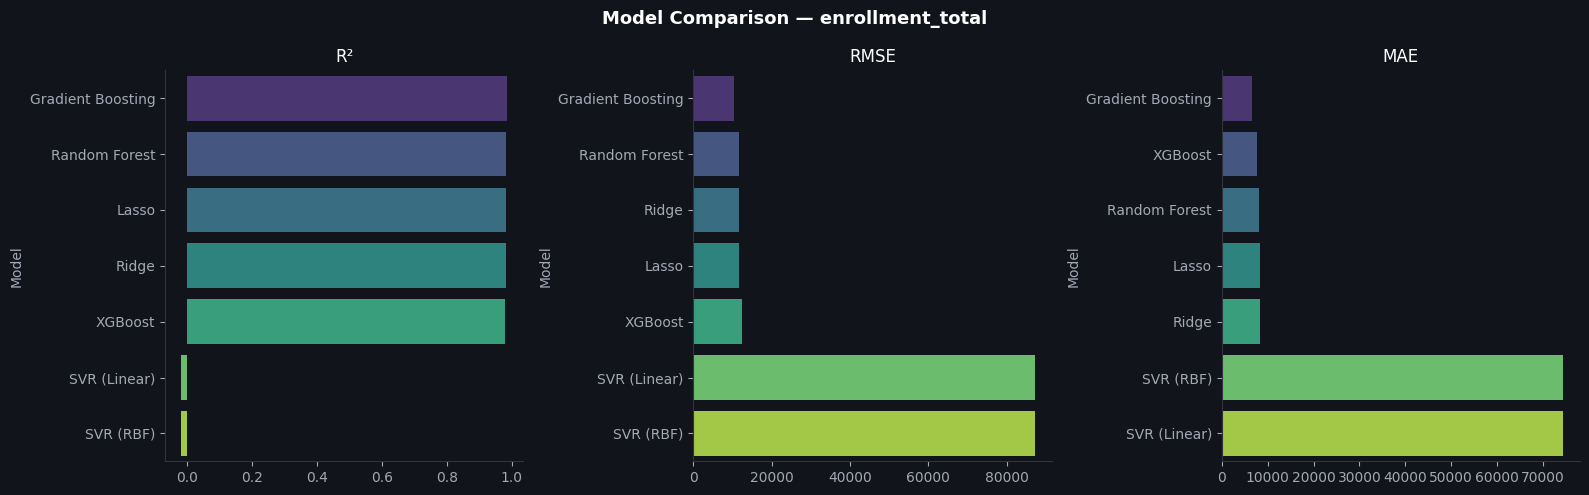

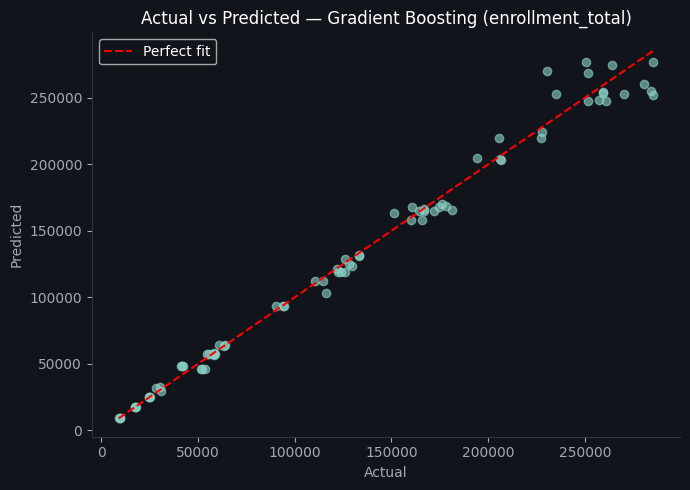

>>> DROPOUT RATE

  TARGET: avg_dropout_rate
            Model      R²   RMSE    MAE
    Random Forest -0.5200 2.1627 1.8641
            Lasso -0.5800 2.2050 1.8589
            Ridge -0.6606 2.2606 1.7801
     SVR (Linear) -0.7389 2.3132 1.8301
          XGBoost -0.8965 2.4158 2.0950
Gradient Boosting -1.1134 2.5502 2.1790
        SVR (RBF) -4.2247 4.0097 3.4619



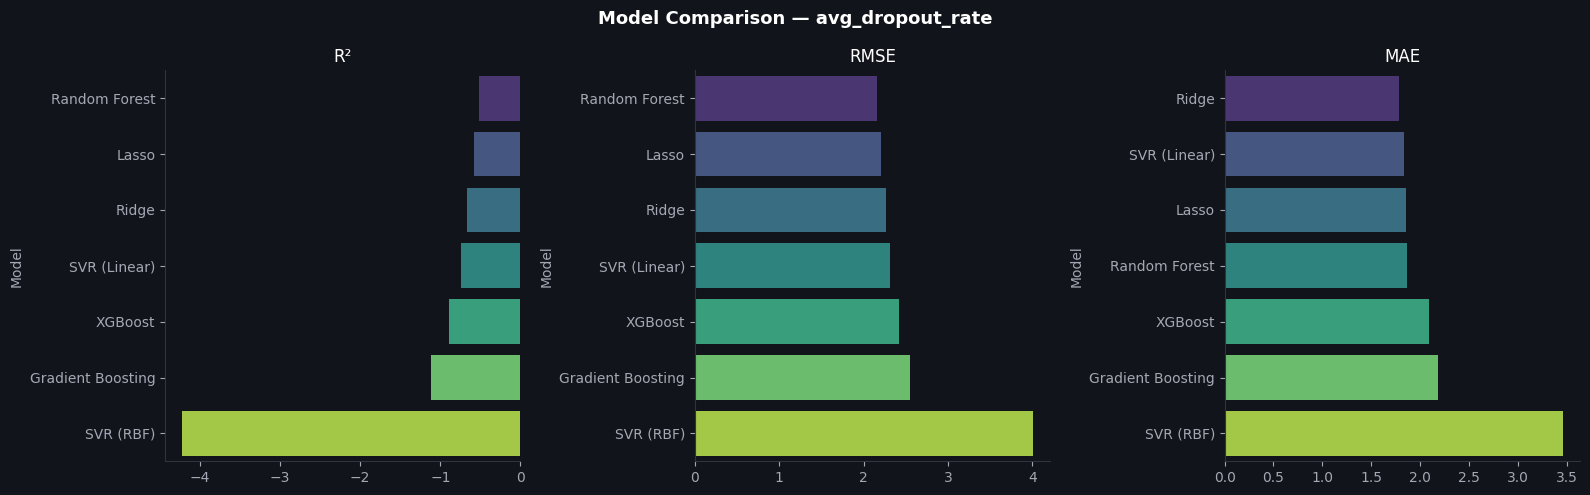

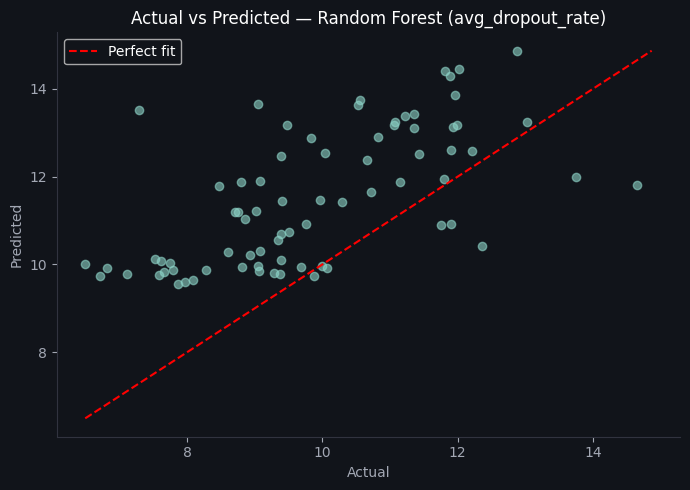

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index
            Model      R²   RMSE    MAE
Gradient Boosting  0.5385 0.1104 0.0860
          XGBoost  0.4869 0.1164 0.0910
    Random Forest  0.3921 0.1267 0.1009
        SVR (RBF)  0.3369 0.1323 0.1025
            Lasso -0.1747 0.1761 0.1349
     SVR (Linear) -0.1984 0.1778 0.1374
            Ridge -0.2263 0.1799 0.1394



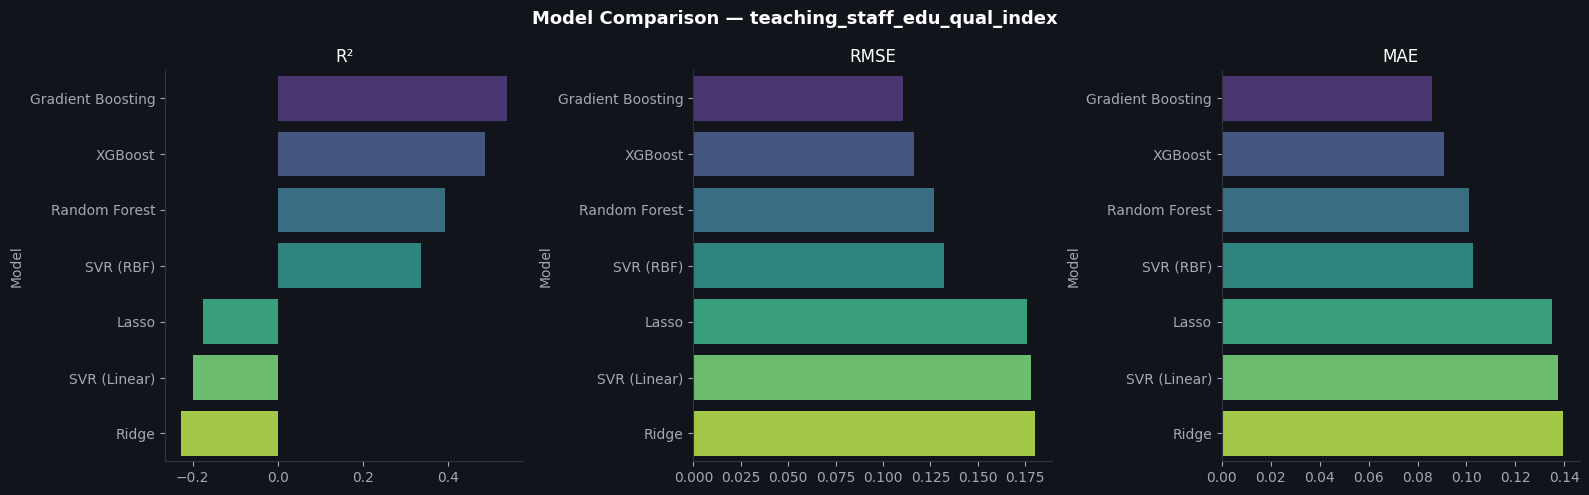

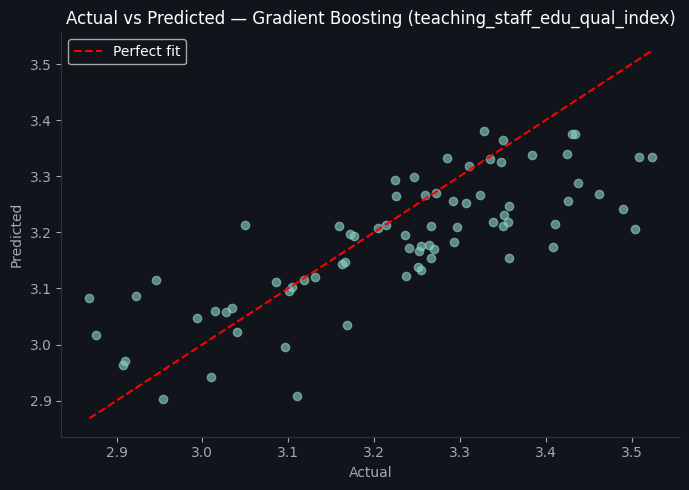

In [103]:

def forecast_compare(df, target, features, train_years=(2016, 2023), test_years=(2024, 2026), log_transform=False):
    """
    Trains multiple models on a time-split, compares MSE/R²/MAE, plots results.
    log_transform=True for skewed ratio targets like dropout rate.
    """

    # --- Prep ---
    feats = [c for c in features if c in df.columns]
    X_raw = df[feats].copy().fillna(np.nan)
    y_raw = df[target].copy()

    train_mask = df['Year'].between(*train_years)
    test_mask  = df['Year'].between(*test_years)

    X_train, X_test = X_raw[train_mask], X_raw[test_mask]
    y_train, y_test = y_raw[train_mask], y_raw[test_mask]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feats)
    X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=feats)

    # Scale for SVR
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc  = scaler.transform(X_test_imp)

    if log_transform:
        y_train_fit = np.log1p(y_train.values)
    else:
        y_train_fit = y_train.values

    # --- Models ---
    models = {
        'Random Forest':       (RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1),  X_train_imp, X_test_imp),
        'Gradient Boosting':   (GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),          X_train_imp, X_test_imp),
        'XGBoost':             (xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),      X_train_imp, X_test_imp),
        'SVR (RBF)':           (SVR(kernel='rbf', C=10, epsilon=0.1),                                                                   X_train_sc,  X_test_sc),
        'SVR (Linear)':        (SVR(kernel='linear', C=1),                                                                              X_train_sc,  X_test_sc),
        'Ridge':               (Ridge(alpha=1.0),                                                                                       X_train_imp, X_test_imp),
        'Lasso':               (Lasso(alpha=0.01, max_iter=5000),                                                                       X_train_imp, X_test_imp),
    }

    # --- Evaluate ---
    records = []
    predictions = {}

    for name, (model, X_tr, X_te) in models.items():
        model.fit(X_tr, y_train_fit)
        y_pred_raw = model.predict(X_te)

        # reverse log if needed
        y_pred = np.expm1(y_pred_raw) if log_transform else y_pred_raw
        y_true = y_test.values

        records.append({
            'Model': name,
            'R²':    round(r2_score(y_true, y_pred), 4),
            'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
            'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        })
        predictions[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R²', ascending=False).reset_index(drop=True)

    # --- Print table ---
    print(f"\n{'='*55}")
    print(f"  TARGET: {target}")
    print(f"{'='*55}")
    print(results_df.to_string(index=False))
    print(f"{'='*55}\n")

    # --- Plot 1: metric comparison bar chart ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
        sorted_df = results_df.sort_values(metric, ascending=(metric != 'R²'))
        sns.barplot(data=sorted_df, x=metric, y='Model', ax=ax,
                    hue='Model', palette='viridis', legend=False)
        ax.set_title(metric)
        ax.set_xlabel('')
    fig.suptitle(f'Model Comparison — {target}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: actual vs predicted for best model ---
    best_model_name = results_df.iloc[0]['Model']
    y_best = predictions[best_model_name]

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test.values, y_best, alpha=0.6)
    lims = [min(y_test.min(), y_best.min()), max(y_test.max(), y_best.max())]
    plt.plot(lims, lims, 'r--', label='Perfect fit')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {best_model_name} ({target})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df, predictions


# ==============================
# Run all 3 models
# ==============================

features_enrollment = [ 'total_staff_total','kids_population', 'num_classrooms',]

features_dropout = ['principal_avg_age', 'principal_avg_service_years',
                    'pct_overage_enrollment_upper_sec', 'sport_volleyball', 'sport_long_jump',
                    'pb_fund_per_school_riel', 'buildings_per_school', 'classes_per_classroom',
                    'pct_overage_admission_total', 'transition_rate_lower_sec_total']

features_teacher = ['schools_without_water', 'schools_without_latrine', 'principal_avg_service_years',
                    'principal_upper_sec_plus_edu', 'buildings_poor_roof', 'pb_fund_per_student_riel',
                    'pb_fund_per_school_riel', 'classrooms_per_school',
                    'gross_admission_rate_total', 'transition_rate_lower_sec_total']

print(">>> ENROLLMENT")
res_enrollment, pred_enrollment = forecast_compare(
    df, target='enrollment_total', features=features_enrollment, log_transform=False)

print(">>> DROPOUT RATE")
res_dropout, pred_dropout = forecast_compare(
    df, target='avg_dropout_rate', features=features_dropout, log_transform=True)

print(">>> TEACHER QUALITY")
res_teacher, pred_teacher = forecast_compare(
    df, target='teaching_staff_edu_qual_index', features=features_teacher, log_transform=False)

In [104]:
def plot_features_grid(df, features, target):
    # Ensure column names match lowercase
    df.columns = [c.lower() for c in df.columns]
    features = [f.lower() for f in features]
    target = target.lower()

    # --- Apply Dark Theme Styling ---
    plt.style.use("dark_background")
    rc_params = {
        "figure.facecolor": "#11141a",
        "axes.facecolor": "#11141a",
        "axes.edgecolor": "#31333f",
        "grid.color": "#31333f",
        "text.color": "#ffffff",
        "axes.labelcolor": "#a3a8b4",
        "xtick.color": "#a3a8b4",
        "ytick.color": "#a3a8b4",
    }
    plt.rcParams.update(rc_params)

    # Setup a dynamic 1-row grid based on the number of features passed
    fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 5))

    # If only 1 feature is passed, convert axes to an array to keep code consistent
    if len(features) == 1:
        axes = [axes]

    fig.suptitle(
        f"Features vs {target.replace('_', ' ').title()}",
        fontsize=22,
        color="#ffffff",
        weight="bold",
    )

    # Vibrant neon/pastel palette
    colors = sns.color_palette("coolwarm", len(features))

    # Loop through features and populate the subplots dynamically
    for i, feature in enumerate(features):
        ax = axes[i]  # Clean 1D array indexing

        if feature in df.columns:
            sns.regplot(
                data=df,
                x=feature,
                y=target,
                ax=ax,
                scatter_kws={"alpha": 0.6, "color": colors[i], "s": 40},
                line_kws={"color": "#ff4b4b", "linewidth": 2},
            )
            ax.set_title(
                feature.replace("_", " ").title(), fontsize=12, color="#ffffff", pad=10
            )
            ax.set_xlabel(feature.replace("_", " ").title(), fontsize=10)
            ax.set_ylabel(target.replace("_", " ").title(), fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.1)
        else:
            ax.text(
                0.5,
                0.5,
                f"Feature '{feature}'\nnot found",
                ha="center",
                va="center",
                fontsize=12,
                color="#ff4b4b",
            )
            ax.axis("off")

    # Adjust layout for neat spacing
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()
def plot_timeseries_grid(df, features, time_col="Year"):
    # Apply clean dark styling
    plt.style.use("dark_background")

    # Setup 3 rows by 5 columns grid
    fig, axes = plt.subplots(3, 5, figsize=(22, 12))
    axes = axes.flatten()  # Flatten to easily loop over 15 slots

    for i, feature in enumerate(features):
        ax = axes[i]
        if feature in df.columns:
            # sns.lineplot automatically aggregates multiple rows per year (e.g. provinces)
            sns.lineplot(
                data=df,
                x=time_col,
                y=feature,
                ax=ax,
                marker="o",
                linewidth=2,
                color="#00d2ff",
            )
            ax.set_title(feature.replace("_", " ").title(), fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.grid(True, linestyle="--", alpha=0.2)
        else:
            ax.axis("off")  # Hide empty subplots if feature is missing

    plt.tight_layout()
    plt.show()

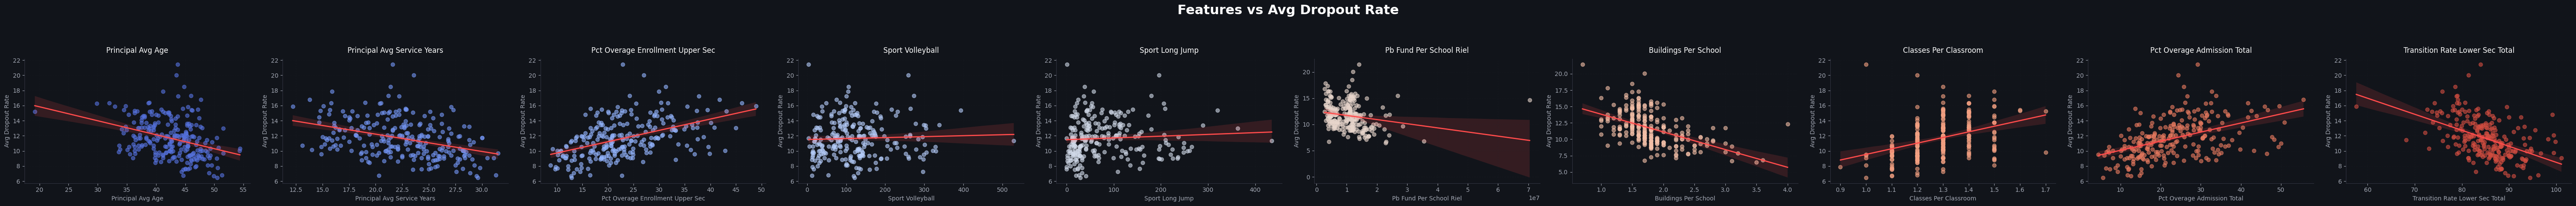

In [105]:
plot_features_grid(df,features_dropout,"avg_dropout_rate")

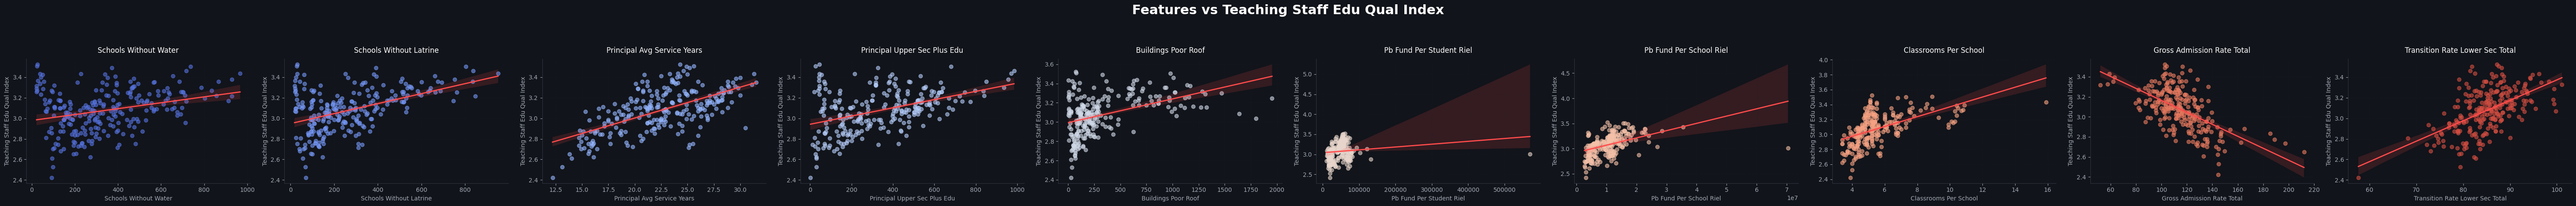

In [106]:
plot_features_grid(df,features_teacher,"teaching_staff_edu_qual_index")

| Feature | Pattern | Verdict | Transform |
| :--- | :--- | :---: | :---: |
| `principal_avg_age` | clean negative linear | ✅ keep | none |
| `principal_avg_service_years` | clean negative linear | ✅ keep | none |
| `pct_overage_enrollment_upper_sec` | positive, slight curve | ✅ keep | `sqrt` |
| `sport_volleyball` | flat, blob | ❌ drop | — |
| `sport_long_jump` | flat, blob | ❌ drop | — |
| `pb_fund_per_school_riel` | negative, heavy curve + extreme outlier squishing | ✅ keep | `log1p` |
| `buildings_per_school` | negative, clear curve — drops fast then flattens | ✅ keep | `1/x`<br>(reciprocal) |
| `classes_per_classroom` | positive linear, discrete x values | ✅ keep | none |
| `pct_overage_admission_total` | positive, slight fan | ✅ keep | `sqrt` |
| `transition_rate_lower_sec_total` | strong negative linear | ✅ keep | none |

In [107]:
from sklearn.preprocessing import PowerTransformer

DROPOUT_LOG_FEATS        = ['pb_fund_per_school_riel']
DROPOUT_SQRT_FEATS       = ['pct_overage_enrollment_upper_sec', 'pct_overage_admission_total']
DROPOUT_RECIPROCAL_FEATS = ['buildings_per_school']
DROPOUT_DROP_FEATS       = ['sport_volleyball', 'sport_long_jump']

def transform_dropout(drop_out, final_drop_out_feature):
    df_out = drop_out.copy()
    final_feats = []

    active = [f for f in final_drop_out_feature
              if f in df_out.columns and f not in DROPOUT_DROP_FEATS]

    for f in active:
        if f in DROPOUT_LOG_FEATS:
            col = f'log_{f}'; df_out[col] = np.log1p(df_out[f]); final_feats.append(col)
        elif f in DROPOUT_SQRT_FEATS:
            col = f'sqrt_{f}'; df_out[col] = np.sqrt(df_out[f]); final_feats.append(col)
        elif f in DROPOUT_RECIPROCAL_FEATS:
            col = f'recip_{f}'; df_out[col] = 1 / df_out[f].replace(0, np.nan); final_feats.append(col)
        else:
            final_feats.append(f)   # already linear — pass through as-is

    return df_out, final_feats
drop_out_transform,features_dropout_transform = transform_dropout (df,features_dropout)

| Feature | Pattern | Transform |
| :--- | :--- | :---: |
| `schools_without_water` | positive, right-skewed x (0–1000) | `log1p` |
| `schools_without_latrine` | positive, right-skewed x (0–900) | `log1p` |
| `principal_avg_service_years` | clean positive linear | none |
| `principal_upper_sec_plus_edu` | positive, right-skewed x (0–1000) | `log1p` |
| `buildings_poor_roof` | positive, heavy right skew + outliers | `log1p` |
| `pb_fund_per_student_riel` | massive outlier crushing everything, flat line | ❌ drop |
| `pb_fund_per_school_riel` | same issue — extreme outlier | ❌ drop |
| `classrooms_per_school` | positive, slight curve, outlier at 16 | `sqrt` |
| `gross_admission_rate_total` | strong negative linear | none |
| `transition_rate_lower_sec_total` | positive linear | none |

In [108]:
TEACHER_LOG_FEATS   = ['schools_without_water', 'schools_without_latrine',
                        'principal_upper_sec_plus_edu', 'buildings_poor_roof']
TEACHER_SQRT_FEATS  = ['classrooms_per_school']
TEACHER_DROP_FEATS  = ['pb_fund_per_student_riel', 'pb_fund_per_school_riel']

def transform_teacher(teacher, final_teacher_feature):
    df_out = teacher.copy()
    final_feats = []

    active = [f for f in final_teacher_feature
              if f in df_out.columns and f not in TEACHER_DROP_FEATS]

    for f in active:
        if f in TEACHER_LOG_FEATS:
            col = f'log_{f}'; df_out[col] = np.log1p(df_out[f]); final_feats.append(col)
        elif f in TEACHER_SQRT_FEATS:
            col = f'sqrt_{f}'; df_out[col] = np.sqrt(df_out[f]); final_feats.append(col)
        else:
            final_feats.append(f)  # linear — pass through

    return df_out, final_feats
teacher_transfrom,features_teacher_transform = transform_teacher(df, features_teacher)

In [109]:
teacher_transfrom = teacher_transfrom.rename(columns={"year": "Year"})
drop_out_transform = drop_out_transform.rename(columns={"year": "Year"})

>>> DROPOUT RATE

  TARGET: avg_dropout_rate
            Model      R²   RMSE    MAE
            Lasso -0.7248 2.3038 1.9395
            Ridge -0.7737 2.3362 1.9352
    Random Forest -0.8984 2.4170 2.0573
     SVR (Linear) -1.0518 2.5127 1.9555
          XGBoost -1.3695 2.7002 2.2916
Gradient Boosting -1.4579 2.7502 2.3842
        SVR (RBF) -4.6478 4.1689 3.7247



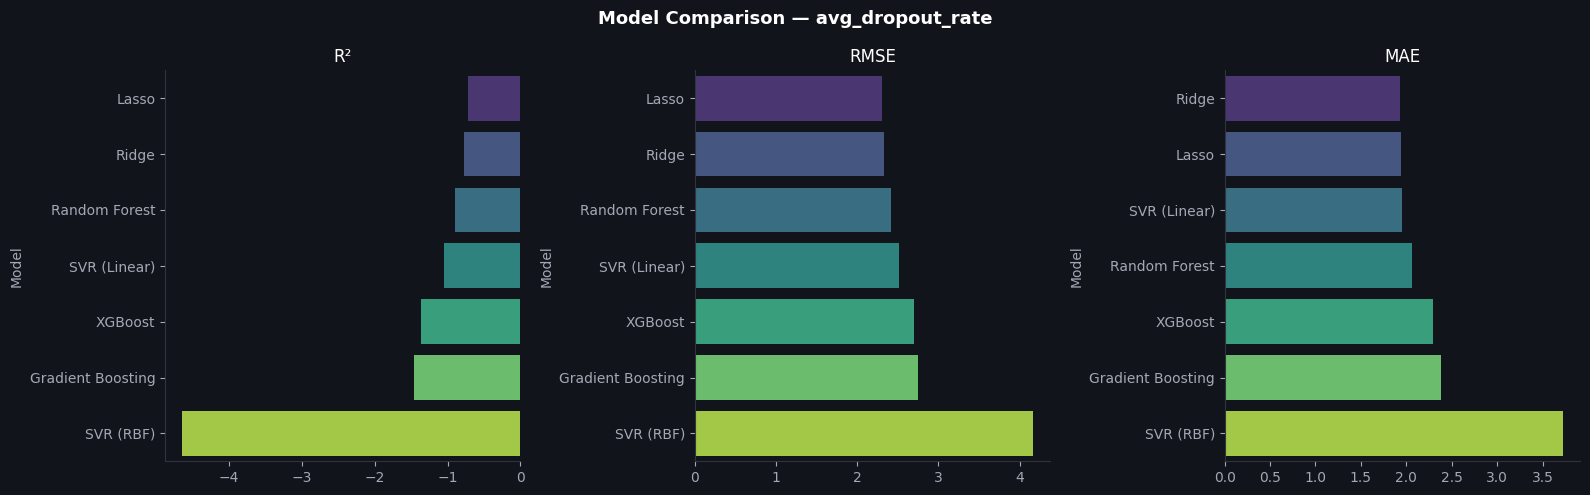

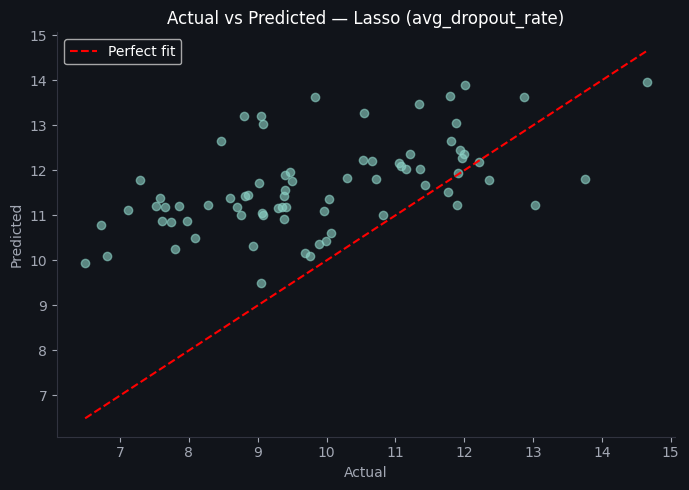

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index
            Model      R²   RMSE    MAE
Gradient Boosting  0.5064 0.1141 0.0916
          XGBoost  0.4532 0.1201 0.0965
    Random Forest  0.3223 0.1337 0.1072
        SVR (RBF)  0.2157 0.1439 0.1139
            Lasso -0.1891 0.1771 0.1352
     SVR (Linear) -0.4288 0.1942 0.1536
            Ridge -0.4560 0.1960 0.1556



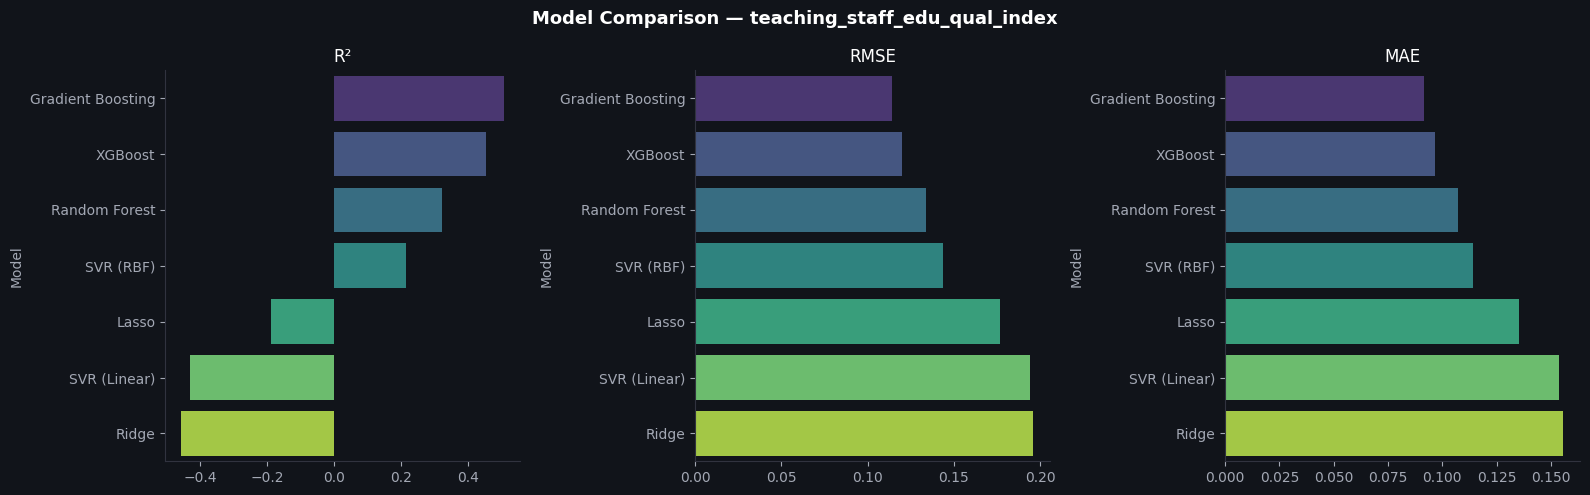

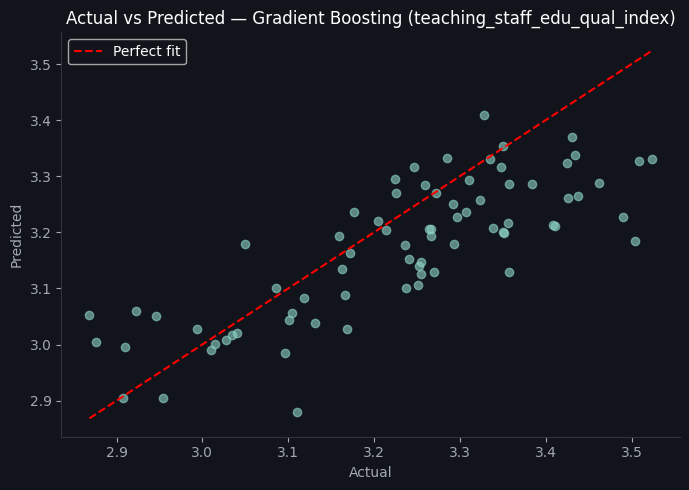

In [110]:

print(">>> DROPOUT RATE")
res_dropout, pred_dropout = forecast_compare(
    drop_out_transform, target='avg_dropout_rate', features=features_dropout_transform, log_transform=True)

print(">>> TEACHER QUALITY")
res_teacher, pred_teacher = forecast_compare(
    teacher_transfrom, target='teaching_staff_edu_qual_index', features=features_teacher_transform, log_transform=False)

In [111]:
def _fit_candidates(x, y):
    """
    Try linear, log, sqrt, and exponential fits.
    Returns the best transform name + predicted y for forecast years,
    chosen by highest R² on the training data.
    """
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    # remove NaNs
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return 'linear', None, -999

    candidates = {}

    # 1. Linear: y ~ x
    X_lin = x.reshape(-1, 1)
    m = LinearRegression().fit(X_lin, y)
    candidates['linear'] = (m, lambda xf: m.predict(xf.reshape(-1,1)),
                             r2_score(y, m.predict(X_lin)))

    # 2. Log: y ~ log(x)  — only if x > 0
    if np.all(x > 0):
        X_log = np.log(x).reshape(-1, 1)
        m2 = LinearRegression().fit(X_log, y)
        candidates['log'] = (m2, lambda xf: m2.predict(np.log(xf).reshape(-1,1)),
                              r2_score(y, m2.predict(X_log)))

    # 3. Sqrt: y ~ sqrt(x)
    if np.all(x >= 0):
        X_sqrt = np.sqrt(x).reshape(-1, 1)
        m3 = LinearRegression().fit(X_sqrt, y)
        candidates['sqrt'] = (m3, lambda xf: m3.predict(np.sqrt(xf).reshape(-1,1)),
                               r2_score(y, m3.predict(X_sqrt)))

    # 4. Exponential: log(y) ~ x  — only if y > 0
    if np.all(y > 0):
        X_exp = x.reshape(-1, 1)
        m4 = LinearRegression().fit(X_exp, np.log(y))
        y_pred_exp = np.exp(m4.predict(X_exp))
        candidates['exp'] = (m4, lambda xf: np.exp(m4.predict(xf.reshape(-1,1))),
                              r2_score(y, y_pred_exp))

    best_name = max(candidates, key=lambda k: candidates[k][2])
    _, pred_fn, best_r2 = candidates[best_name]
    return best_name, pred_fn, best_r2


def project_features_to_2030(df, feature_list, year_col='year', target_years=None, r2_threshold=0.5):
    """
    Projects each feature in feature_list to 2030 using national averages.
    Auto-selects best fit (linear / log / sqrt / exp) per feature based on R².

    Parameters
    ----------
    df            : full dataframe with Year column and feature columns
    feature_list  : list of feature names to project
    year_col      : name of the year column (default 'Year')
    target_years  : list of years to forecast (default [2027, 2028, 2029, 2030])
    r2_threshold  : features with R² below this use flat historical mean (default 0.5)

    Returns
    -------
    projected_df : dataframe with columns [Year] + feature_list for forecast years
    fit_summary  : dataframe showing which fit was chosen + R² per feature
    """
    if target_years is None:
        target_years = [2027, 2028, 2029, 2030]

    # national average per year
    national = df.groupby(year_col)[feature_list].mean().reset_index()

    projected_rows = {year_col: target_years}
    summary = []

    for feat in feature_list:
        if feat not in national.columns:
            print(f"  [skip] {feat} not in dataframe")
            continue

        x_train = national[year_col].values
        y_train = national[feat].values
        x_fore  = np.array(target_years, dtype=float)
        hist_mean = float(np.nanmean(y_train))

        best_name, pred_fn, best_r2 = _fit_candidates(x_train, y_train)

        if pred_fn is None or best_r2 < r2_threshold:
            # low R² or insufficient data — flat projection at historical mean
            projected_rows[feat] = [hist_mean] * len(target_years)
            label = 'flat (low R²)' if pred_fn is not None else 'flat (no data)'
            summary.append({'feature': feat, 'best_fit': label,
                            'r2': round(best_r2, 4) if pred_fn else np.nan,
                            'projected_as': f'mean={hist_mean:.4f}'})
            continue

        y_fore = pred_fn(x_fore)
        projected_rows[feat] = list(y_fore)
        summary.append({'feature': feat, 'best_fit': best_name,
                        'r2': round(best_r2, 4), 'projected_as': 'trend'})

    projected_df = pd.DataFrame(projected_rows)
    fit_summary  = pd.DataFrame(summary).sort_values('r2', ascending=False).reset_index(drop=True)

    return projected_df, fit_summary


# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
if __name__ == '__main__':
    
    features_enrollment = [ 'total_staff_total','kids_population', 'num_classrooms',]

    # dropout features
    final_drop_out_feature = [
        'pct_overage_enrollment_upper_sec',
        'principal_avg_age',
        'principal_avg_service_years',
        'pb_fund_per_school_riel',
        'buildings_per_school',
        'classes_per_classroom',
        'pct_overage_admission_total',
        'transition_rate_lower_sec_total',
    ]

    # teacher features
    final_teacher_feature = [
        'schools_without_water',
        'schools_without_latrine',
        'principal_avg_service_years',
        'principal_upper_sec_plus_edu',
        'buildings_poor_roof',
        'classrooms_per_school',
        'gross_admission_rate_total',
        'transition_rate_lower_sec_total',
    ]

    all_features = list(set(final_drop_out_feature + final_teacher_feature +features_enrollment))

    projected_df, fit_summary = project_features_to_2030(df, all_features)

    print("\n=== Fit summary ===")
    print(fit_summary.to_string(index=False))

    print("\n=== Projected values (2027–2030) ===")
    print(projected_df.to_string(index=False))


=== Fit summary ===
                         feature      best_fit     r2     projected_as
     principal_avg_service_years           exp 0.9754            trend
                  num_classrooms           log 0.9559            trend
         pb_fund_per_school_riel           log 0.8564            trend
               total_staff_total           log 0.8318            trend
         schools_without_latrine           exp 0.8026            trend
      gross_admission_rate_total           exp 0.7392            trend
           classes_per_classroom        linear 0.7288            trend
           schools_without_water           log 0.5008            trend
             buildings_poor_roof           log 0.5001            trend
           classrooms_per_school flat (low R²) 0.4920      mean=5.5216
 transition_rate_lower_sec_total flat (low R²) 0.4880     mean=85.0284
    principal_upper_sec_plus_edu flat (low R²) 0.4103    mean=334.7360
     pct_overage_admission_total flat (low R²) 0.3902   

saved to projection_charts.png


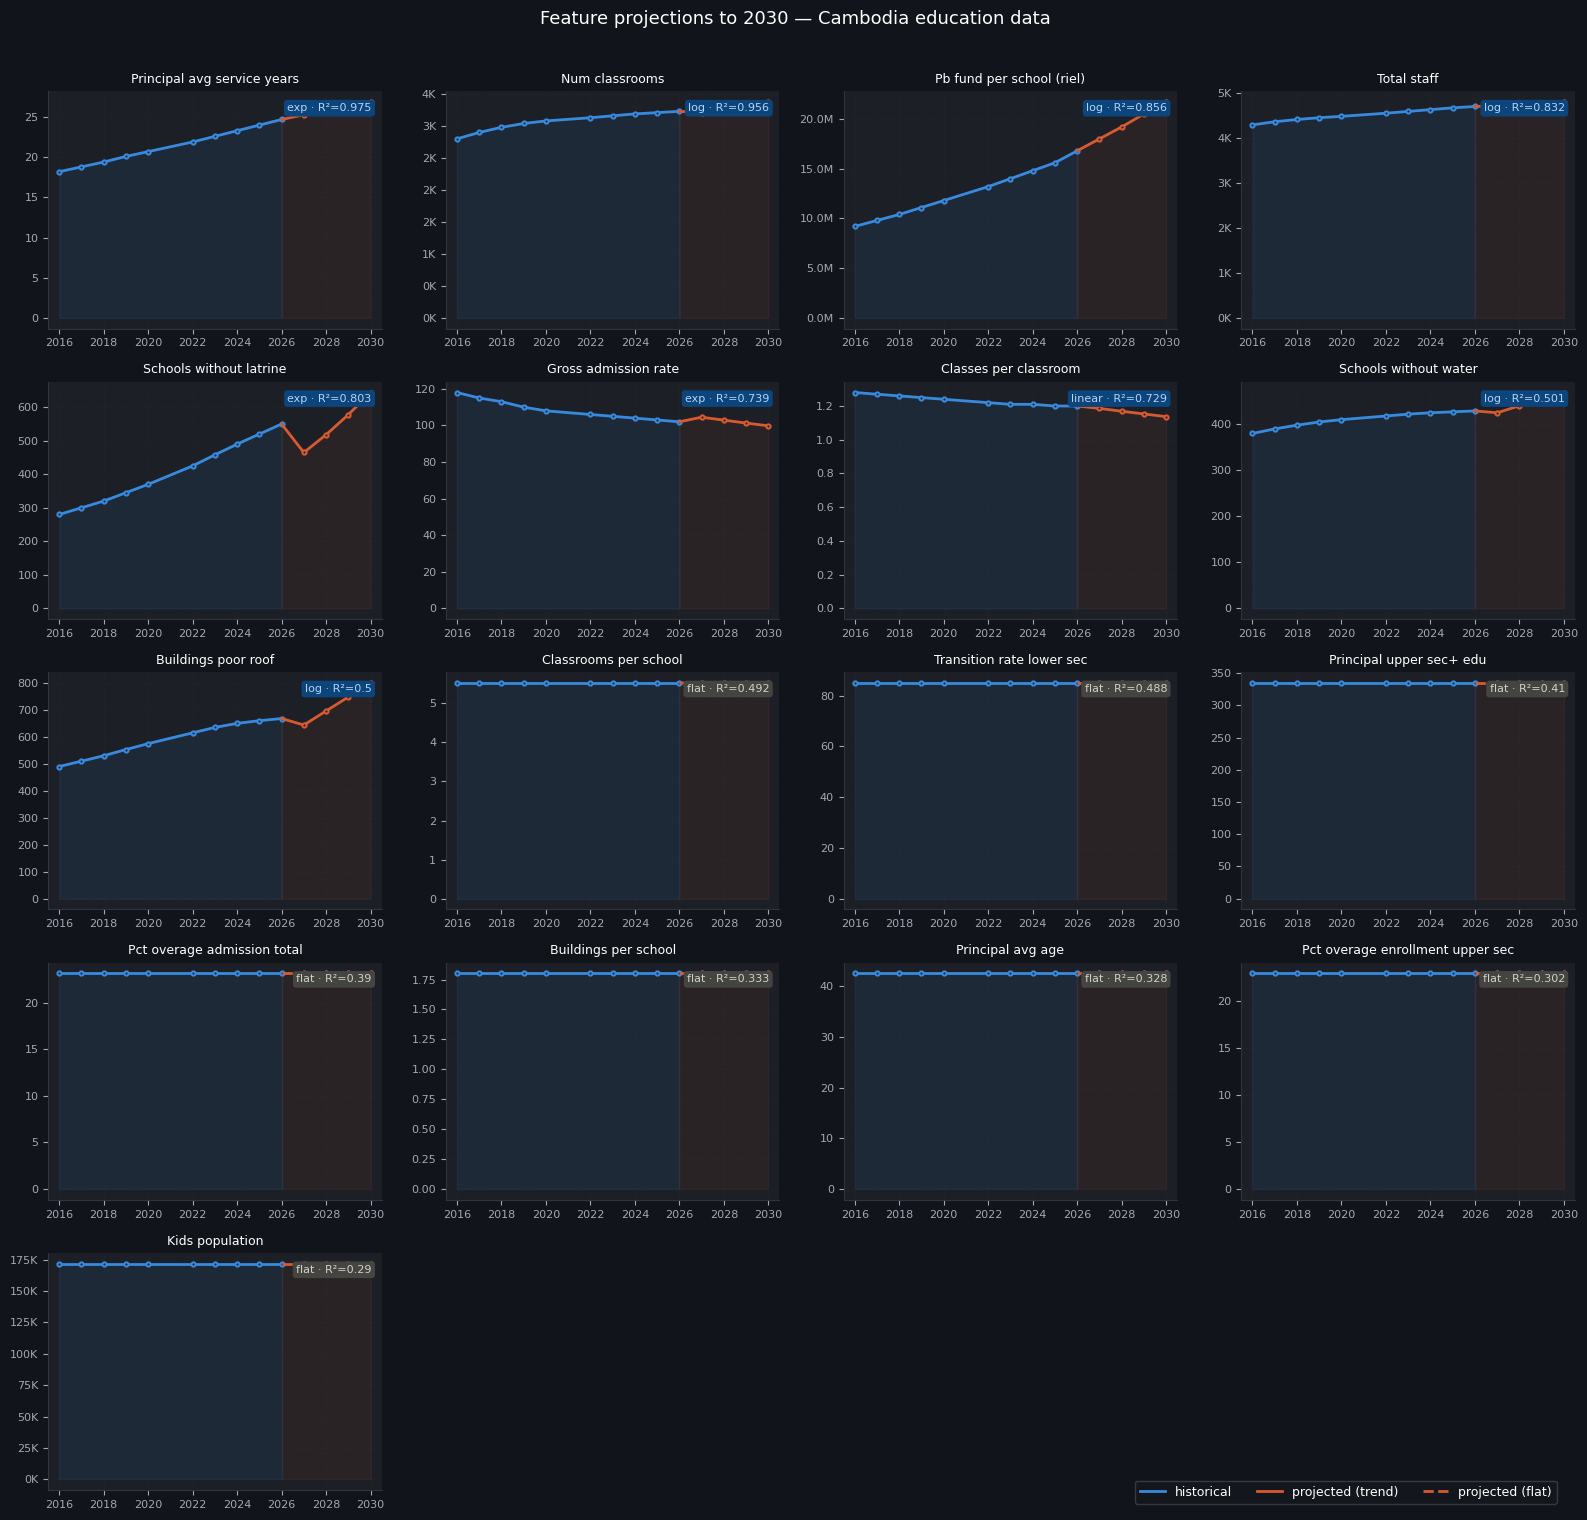

In [112]:
plt.style.use('dark_background')
DARK_BG = '#11141a'
SURFACE = '#1c1f26'
BORDER  = '#31333f'
MUTED   = '#a3a8b4'
BLUE    = '#378ADD'
CORAL   = '#D85A30'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': SURFACE,
    'axes.edgecolor': BORDER, 'grid.color': BORDER,
    'text.color': '#ffffff', 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})

HIST_YEARS = [2016,2017,2018,2019,2020,2022,2023,2024,2025,2026]
PROJ_YEARS = [2027,2028,2029,2030]

features = [
    dict(name='principal_avg_service_years', label='Principal avg service years', r2=0.975, fit='exp',
         hist=[18.2,18.8,19.4,20.1,20.7,21.9,22.6,23.3,24.0,24.7],
         proj=[25.28,25.79,26.32,26.86]),
    dict(name='num_classrooms', label='Num classrooms', r2=0.956, fit='log',
         hist=[2800,2900,2980,3040,3080,3130,3160,3190,3210,3230],
         proj=[3209,3264,3319,3374]),
    dict(name='pb_fund_per_school_riel', label='Pb fund per school (riel)', r2=0.856, fit='log',
         hist=[9.2e6,9.8e6,10.4e6,11.1e6,11.8e6,13.2e6,14.0e6,14.8e6,15.6e6,16.8e6],
         proj=[1.80e7,1.92e7,2.05e7,2.17e7]),
    dict(name='total_staff_total', label='Total staff', r2=0.832, fit='log',
         hist=[4300,4370,4420,4460,4490,4560,4600,4640,4680,4710],
         proj=[4722,4750,4778,4807]),
    dict(name='schools_without_latrine', label='Schools without latrine', r2=0.803, fit='exp',
         hist=[280,300,320,345,370,425,458,490,520,550],
         proj=[465,518,578,644]),
    dict(name='gross_admission_rate_total', label='Gross admission rate', r2=0.739, fit='exp',
         hist=[118,115,113,110,108,106,105,104,103,102],
         proj=[104.5,102.9,101.3,99.8]),
    dict(name='classes_per_classroom', label='Classes per classroom', r2=0.729, fit='linear',
         hist=[1.28,1.27,1.26,1.25,1.24,1.22,1.21,1.21,1.20,1.20],
         proj=[1.186,1.169,1.153,1.137]),
    dict(name='schools_without_water', label='Schools without water', r2=0.501, fit='log',
         hist=[380,390,398,405,410,418,422,425,427,429],
         proj=[425,440,454,469]),
    dict(name='buildings_poor_roof', label='Buildings poor roof', r2=0.500, fit='log',
         hist=[490,510,530,553,575,615,635,650,660,668],
         proj=[644,696,748,800]),
    dict(name='classrooms_per_school', label='Classrooms per school', r2=0.492, fit='flat',
         hist=[5.52]*10, proj=[5.5216]*4),
    dict(name='transition_rate_lower_sec_total', label='Transition rate lower sec', r2=0.488, fit='flat',
         hist=[85.03]*10, proj=[85.03]*4),
    dict(name='principal_upper_sec_plus_edu', label='Principal upper sec+ edu', r2=0.410, fit='flat',
         hist=[334.74]*10, proj=[334.74]*4),
    dict(name='pct_overage_admission_total', label='Pct overage admission total', r2=0.390, fit='flat',
         hist=[23.14]*10, proj=[23.14]*4),
    dict(name='buildings_per_school', label='Buildings per school', r2=0.333, fit='flat',
         hist=[1.8016]*10, proj=[1.8016]*4),
    dict(name='principal_avg_age', label='Principal avg age', r2=0.328, fit='flat',
         hist=[42.60]*10, proj=[42.60]*4),
    dict(name='pct_overage_enrollment_upper_sec', label='Pct overage enrollment upper sec', r2=0.302, fit='flat',
         hist=[22.95]*10, proj=[22.95]*4),
    dict(name='kids_population', label='Kids population', r2=0.290, fit='flat',
         hist=[171691]*10, proj=[171691]*4),
]


def plot_projections(features, ncols=4, save_path=None):
    n     = len(features)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4, nrows * 3),
                             facecolor=DARK_BG)
    axes = axes.flatten()

    for i, f in enumerate(features):
        ax    = axes[i]
        isflat = f['fit'] == 'flat'

        hist_x = np.array(HIST_YEARS)
        hist_y = np.array(f['hist'])
        proj_x = np.array(PROJ_YEARS)
        proj_y = np.array(f['proj'])

        # connect last hist point to first proj point
        join_x = np.array([HIST_YEARS[-1], PROJ_YEARS[0]])
        join_y = np.array([f['hist'][-1],  f['proj'][0]])

        ax.plot(hist_x, hist_y, color=BLUE, linewidth=2, marker='o',
                markersize=3, markerfacecolor=SURFACE, markeredgewidth=1.5)
        ax.fill_between(hist_x, hist_y, alpha=0.10, color=BLUE)

        ax.plot(join_x, join_y, color=CORAL, linewidth=2,
                linestyle='--' if isflat else '-')
        ax.plot(proj_x, proj_y, color=CORAL, linewidth=2,
                linestyle='--' if isflat else '-',
                marker='o', markersize=3,
                markerfacecolor=SURFACE, markeredgewidth=1.5,
                label='projected')
        ax.fill_between(np.concatenate([join_x, proj_x]),
                        np.concatenate([join_y, proj_y]),
                        alpha=0.08, color=CORAL)

        # R² badge in top-right corner
        badge_color = '#0C447C' if not isflat else '#444441'
        ax.text(0.97, 0.95, f"{f['fit']} · R²={f['r2']}",
                transform=ax.transAxes, fontsize=8, ha='right', va='top',
                color='#B5D4F4' if not isflat else '#D3D1C7',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=badge_color, edgecolor='none'))

        ax.set_title(f['label'], fontsize=9, color='#ffffff', pad=6)
        ax.set_xlim(2015.5, 2030.5)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
        ax.tick_params(labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.2)

        # format y-axis for large numbers
        max_val = max(max(hist_y), max(proj_y))
        if max_val >= 1e6:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
        elif max_val >= 1e3:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))

    # turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # shared legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=BLUE,  linewidth=2, label='historical'),
        Line2D([0], [0], color=CORAL, linewidth=2, label='projected (trend)'),
        Line2D([0], [0], color=CORAL, linewidth=2, linestyle='--', label='projected (flat)'),
    ]
    fig.legend(handles=legend_elements, loc='lower right',
               fontsize=9, framealpha=0.2, ncol=3,
               bbox_to_anchor=(0.98, 0.01))

    fig.suptitle('Feature projections to 2030 — Cambodia education data',
                 fontsize=13, color='#ffffff', weight='500', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=DARK_BG)
        print(f"saved to {save_path}")

    plt.show()


if __name__ == '__main__':
    plot_projections(features, ncols=4, save_path='projection_charts.png')

>>> ENROLLMENT

  TARGET: enrollment_total  |  Predicted 2027–2030
      Random Forest  Gradient Boosting        XGBoost    SVR (RBF)  SVR (Linear)        Ridge        Lasso
year                                                                                                      
2027    130461.5261        128078.8683  127778.601562  123428.5810   123280.9107  138506.1042  138506.1043
2028    130935.1999        128078.8683  127299.625000  123446.4528   123289.6875  140067.8918  140067.8919
2029    132327.8037        129775.2343  127777.468750  123464.0969   123298.4600  141628.9094  141628.9095
2030    132664.7213        130279.2899  127777.468750  123481.4908   123307.2282  143189.1579  143189.1580



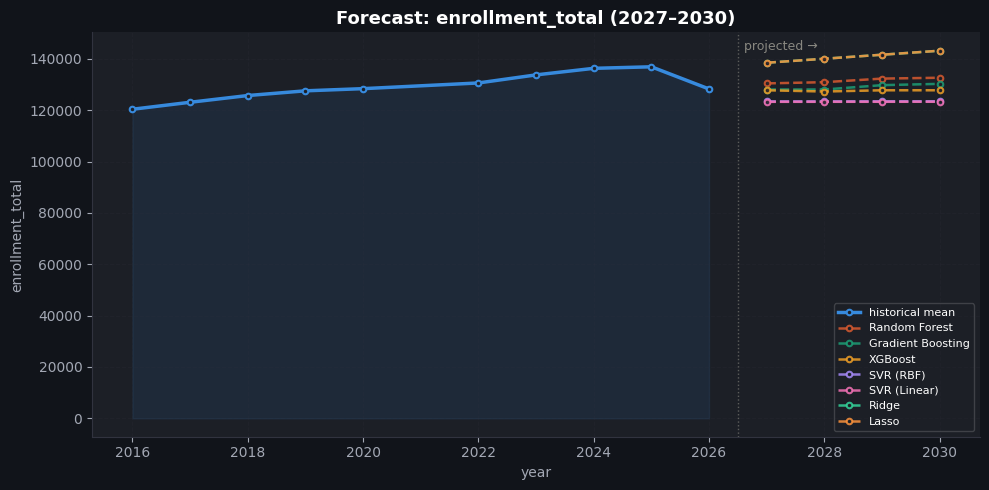

>>> DROPOUT RATE

  TARGET: avg_dropout_rate  |  Predicted 2027–2030
      Random Forest  Gradient Boosting  XGBoost  SVR (RBF)  SVR (Linear)    Ridge    Lasso
year                                                                                      
2027        11.7941            11.4959  12.4245    13.2621       11.5389  11.6770  11.4652
2028        11.7941            11.4959  12.4245    13.4540       11.5760  11.7270  11.4755
2029        11.8427            11.4959  12.4169    13.5245       11.6148  11.7787  11.4863
2030        11.6781            11.4743  12.4169    13.4761       11.6553  11.8321  11.4977



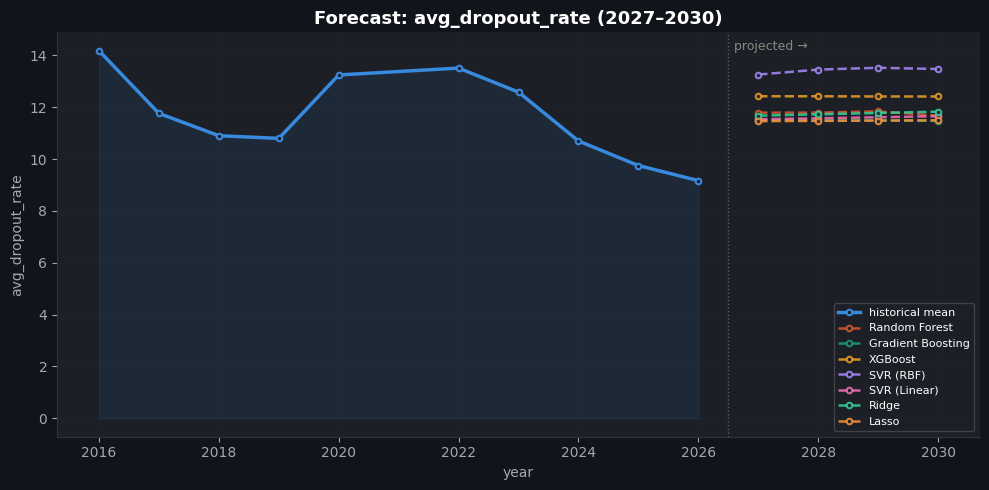

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index  |  Predicted 2027–2030
      Random Forest  Gradient Boosting  XGBoost  SVR (RBF)  SVR (Linear)   Ridge   Lasso
year                                                                                    
2027         3.2832             3.2865   3.3129     3.3695        3.1729  3.1977  3.2048
2028         3.2663             3.2948   3.3087     3.3845        3.1986  3.2265  3.2350
2029         3.2713             3.2878   3.2912     3.3872        3.2268  3.2579  3.2679
2030         3.2695             3.2922   3.2919     3.3771        3.2578  3.2924  3.3038



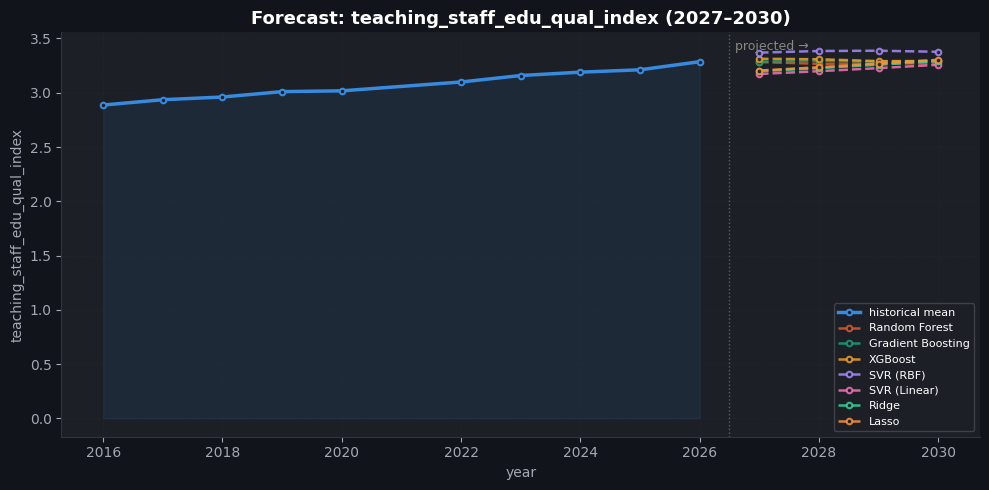

In [113]:
def forecast_on_projected(df, projected_df, target, features,
                           train_years=(2016, 2026), log_transform=False):
    """
    Trains on real data (2016–2026), then predicts on projected feature values (2027–2030).
    No test R²/RMSE since we don't have ground truth for future years.

    Parameters
    ----------
    df           : real dataframe with Year, features, and target columns
    projected_df : output of project_features_to_2030() — rows for 2027–2030
    target       : target column name
    features     : list of feature column names
    train_years  : tuple (start, end) for training slice
    log_transform: if True, fits on log1p(y) and inverse-transforms predictions
    """

    feats = [c for c in features if c in df.columns and c in projected_df.columns]

    # --- Train set ---
    train_mask  = df['year'].between(*train_years)
    X_train_raw = df.loc[train_mask, feats].copy()
    y_train_raw = df.loc[train_mask, target].copy()

    # --- Future set ---
    X_future_raw = projected_df[feats].copy()
    future_years = projected_df['year'].values if 'year' in projected_df.columns \
                   else projected_df['year'].values

    # --- Impute ---
    imputer     = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feats)
    X_future_imp = pd.DataFrame(imputer.transform(X_future_raw),   columns=feats)

    # --- Scale for SVR ---
    scaler       = StandardScaler()
    X_train_sc   = scaler.fit_transform(X_train_imp)
    X_future_sc  = scaler.transform(X_future_imp)

    y_train_fit = np.log1p(y_train_raw.values) if log_transform else y_train_raw.values

    # --- Models ---
    models = {
        'Random Forest':     (RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1), X_train_imp, X_future_imp),
        'Gradient Boosting': (GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),         X_train_imp, X_future_imp),
        'XGBoost':           (xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),     X_train_imp, X_future_imp),
        'SVR (RBF)':         (SVR(kernel='rbf',    C=10, epsilon=0.1),                                                               X_train_sc,  X_future_sc),
        'SVR (Linear)':      (SVR(kernel='linear', C=1),                                                                             X_train_sc,  X_future_sc),
        'Ridge':             (Ridge(alpha=1.0),                                                                                      X_train_imp, X_future_imp),
        'Lasso':             (Lasso(alpha=0.01, max_iter=5000),                                                                      X_train_imp, X_future_imp),
    }

    # --- Predict ---
    predictions = {}
    for name, (model, X_tr, X_fu) in models.items():
        model.fit(X_tr, y_train_fit)
        y_pred_raw = model.predict(X_fu)
        predictions[name] = np.expm1(y_pred_raw) if log_transform else y_pred_raw

    # --- Results table: predicted value per year per model ---
    results_df = pd.DataFrame(predictions, index=future_years)
    results_df.index.name = 'year'

    print(f"\n{'='*65}")
    print(f"  TARGET: {target}  |  Predicted 2027–2030")
    print(f"{'='*65}")
    print(results_df.round(4).to_string())
    print(f"{'='*65}\n")

    # --- Plot: all model predictions over future years ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # historical mean trend for context
    hist_mean = df[df['year'].between(*train_years)].groupby('year')[target].mean()
    ax.plot(hist_mean.index, hist_mean.values,
            color='#378ADD', linewidth=2.5, marker='o', markersize=4,
            markerfacecolor='#1c1f26', markeredgewidth=1.5, label='historical mean')
    ax.fill_between(hist_mean.index, hist_mean.values, alpha=0.10, color='#378ADD')

    # one line per model for 2027–2030
    palette = ['#D85A30','#1D9E75','#EF9F27','#a78bfa','#f472b6','#34d399','#fb923c']
    for (name, preds), color in zip(predictions.items(), palette):
        ax.plot(future_years, preds,
                color=color, linewidth=1.8, marker='o', markersize=4,
                markerfacecolor='#1c1f26', markeredgewidth=1.5,
                linestyle='--', label=name, alpha=0.85)

    # divider line
    ax.axvline(x=2026.5, color='#888780', linewidth=1, linestyle=':', alpha=0.6)
    ax.text(2026.6, ax.get_ylim()[1] * 0.98, 'projected →',
            fontsize=9, color='#888780', va='top')

    ax.set_title(f'Forecast: {target} (2027–2030)', fontsize=13, fontweight='bold')
    ax.set_xlabel('year')
    ax.set_ylabel(target)
    ax.legend(fontsize=8, loc='best', framealpha=0.2)
    ax.grid(True, linestyle='--', alpha=0.2)
    plt.tight_layout()
    plt.show()

    return results_df, predictions


# ==============================
# Run all 3 targets
# ==============================

# projected_df comes from project_features_to_2030()
# projected_df, fit_summary = project_features_to_2030(df, all_features)

features_enrollment = ['total_staff_total', 'kids_population', 'num_classrooms']

features_dropout = ['principal_avg_age', 'principal_avg_service_years',
                    'pct_overage_enrollment_upper_sec', 'pb_fund_per_school_riel',
                    'buildings_per_school', 'classes_per_classroom',
                    'pct_overage_admission_total', 'transition_rate_lower_sec_total']

features_teacher = ['schools_without_water', 'schools_without_latrine',
                    'principal_avg_service_years', 'principal_upper_sec_plus_edu',
                    'buildings_poor_roof', 'classrooms_per_school',
                    'gross_admission_rate_total', 'transition_rate_lower_sec_total']

print(">>> ENROLLMENT")
res_enrollment, pred_enrollment = forecast_on_projected(
    df, projected_df, target='enrollment_total',
    features=features_enrollment, log_transform=False)

print(">>> DROPOUT RATE")
res_dropout, pred_dropout = forecast_on_projected(
    df, projected_df, target='avg_dropout_rate',
    features=features_dropout, log_transform=True)

print(">>> TEACHER QUALITY")
res_teacher, pred_teacher = forecast_on_projected(
    df, projected_df, target='teaching_staff_edu_qual_index',
    features=features_teacher, log_transform=False)

>>> ENROLLMENT

  TARGET: enrollment_total
  Validation: 2024–2026
            Model      R²       RMSE        MAE
Gradient Boosting  0.9857 10310.6670  6605.0897
    Random Forest  0.9819 11619.2926  8163.7575
            Lasso  0.9818 11637.5975  8418.6972
            Ridge  0.9818 11637.5974  8418.6972
          XGBoost  0.9790 12497.4955  7681.3289
     SVR (Linear) -0.0182 87113.6144 74338.4045
        SVR (RBF) -0.0183 87117.2056 74279.6109

  ✔ Best model: Gradient Boosting  (R²=0.9857)

  Forecast 2027–2030:
 year  enrollment_total_forecast
 2027                128078.8683
 2028                128078.8683
 2029                129775.2343
 2030                130279.2899



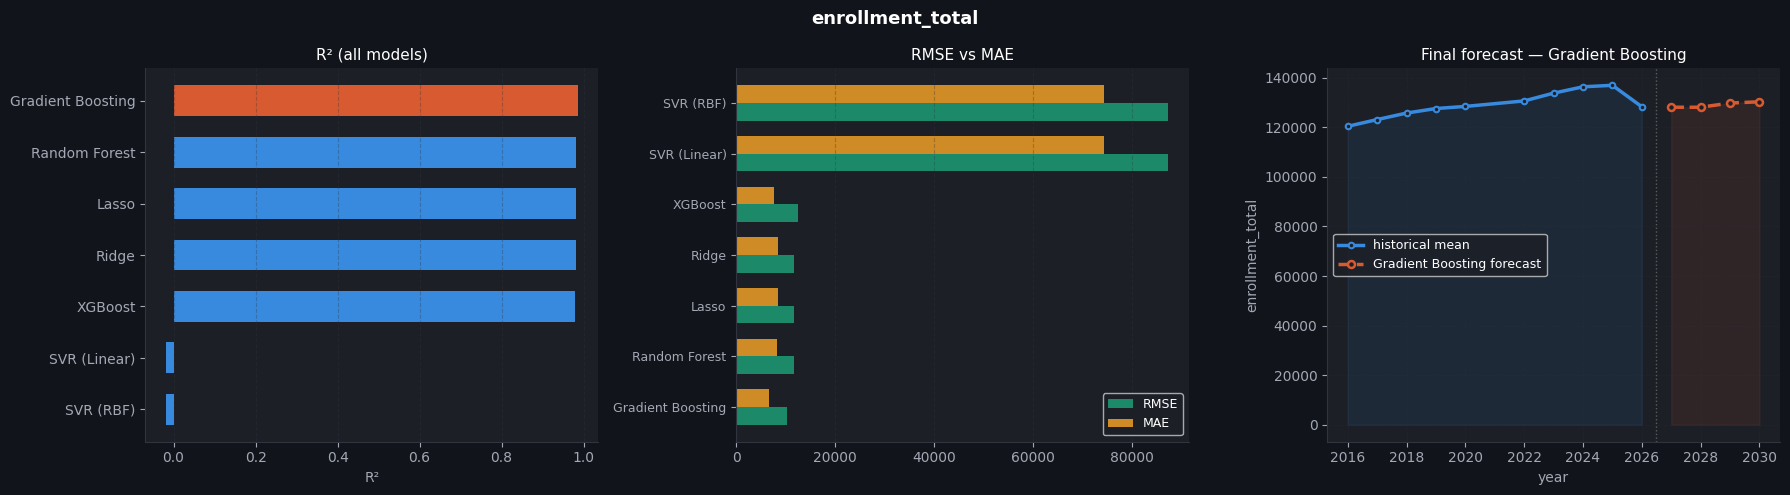

>>> DROPOUT RATE

  TARGET: avg_dropout_rate
  Validation: 2024–2026
            Model      R²   RMSE    MAE
            Lasso -0.7106 2.2943 1.9626
            Ridge -0.8730 2.4007 1.9133
    Random Forest -0.9057 2.4216 2.0611
     SVR (Linear) -0.9322 2.4384 1.9222
          XGBoost -1.3662 2.6984 2.2847
Gradient Boosting -1.4776 2.7612 2.4022
        SVR (RBF) -4.2081 4.0033 3.4748

  ✔ Best model: Lasso  (R²=-0.7106)

  Forecast 2027–2030:
 year  avg_dropout_rate_forecast
 2027                    11.4652
 2028                    11.4755
 2029                    11.4863
 2030                    11.4977



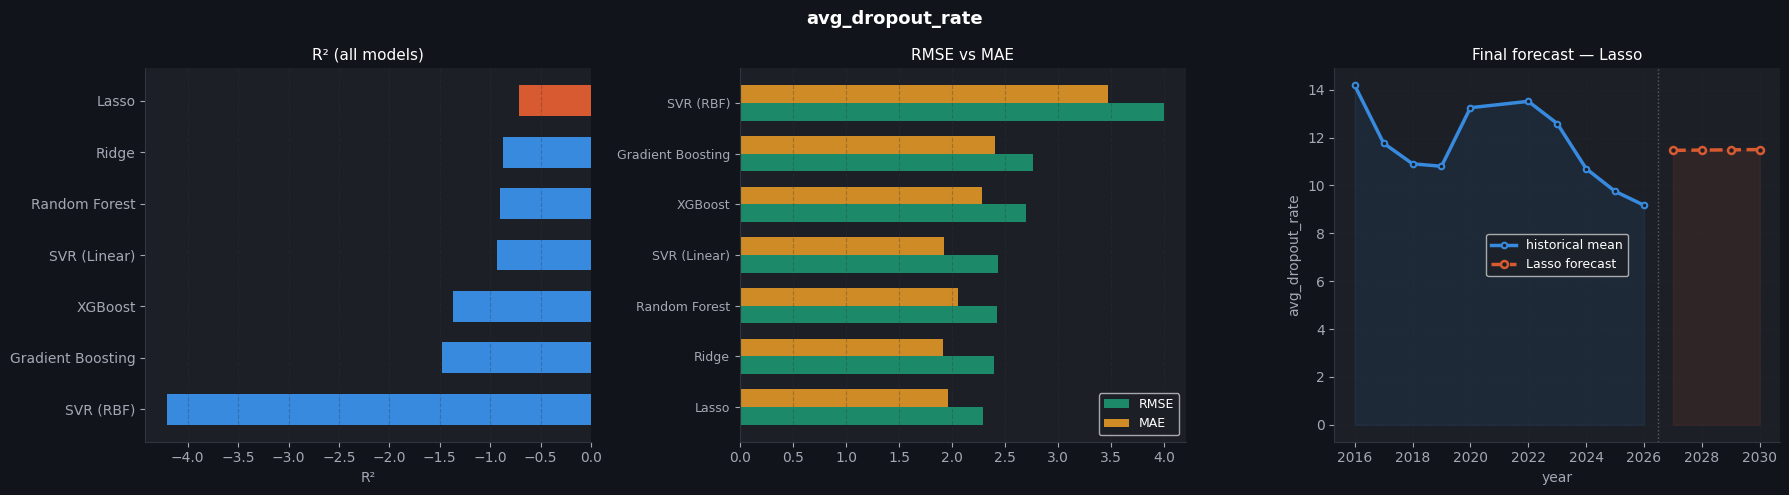

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index
  Validation: 2024–2026
            Model      R²   RMSE    MAE
Gradient Boosting  0.5068 0.1141 0.0920
          XGBoost  0.4532 0.1201 0.0965
    Random Forest  0.3237 0.1336 0.1069
        SVR (RBF)  0.0762 0.1561 0.1261
            Lasso -0.2838 0.1841 0.1430
            Ridge -0.3447 0.1884 0.1474
     SVR (Linear) -0.4814 0.1977 0.1582

  ✔ Best model: Gradient Boosting  (R²=0.5068)

  Forecast 2027–2030:
 year  teaching_staff_edu_qual_index_forecast
 2027                                  3.2865
 2028                                  3.2948
 2029                                  3.2878
 2030                                  3.2922



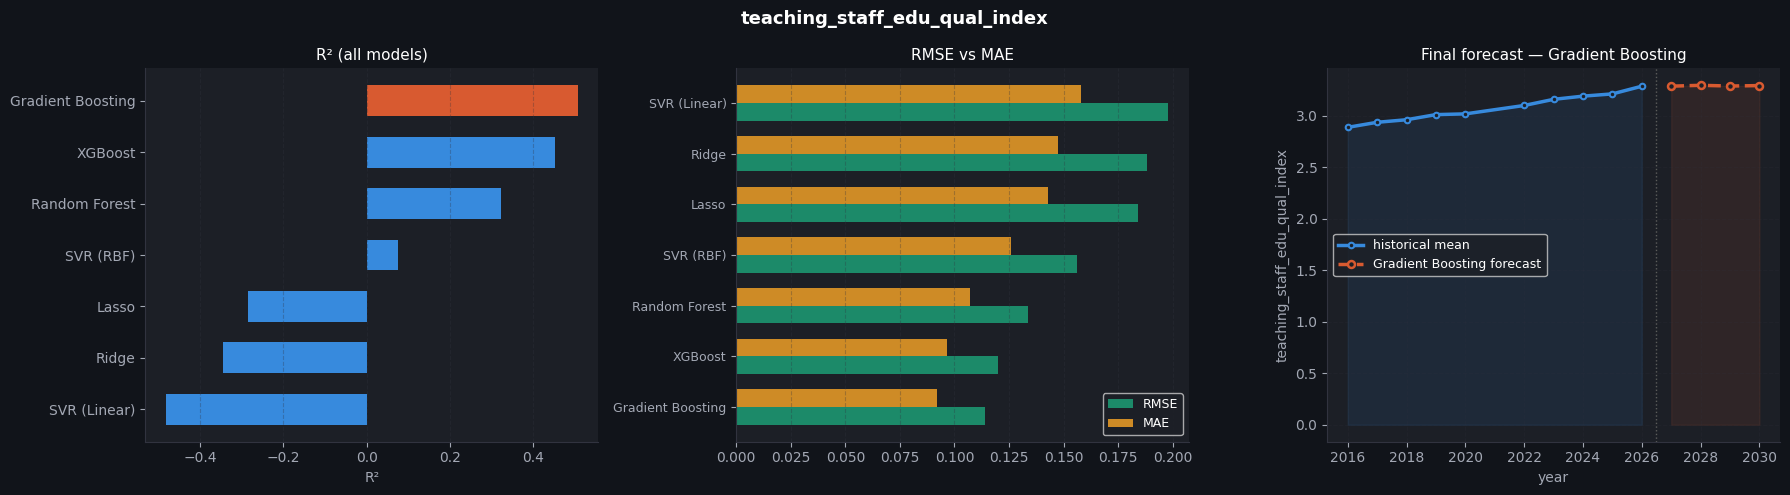

In [115]:
def select_and_forecast(df, projected_df, target, features,
                         train_years=(2016, 2023), val_years=(2024, 2026),
                         log_transform=False):
    """
    1. Trains all models on train_years, evaluates on val_years (real data).
    2. Prints R², RMSE, MAE for all models.
    3. Picks the best model by R².
    4. Retrains best model on full real data (train + val years).
    5. Predicts on projected 2027–2030 features.
    6. Plots: metric comparison + actual vs predicted (val) + final forecast.

    Parameters
    ----------
    df           : real dataframe
    projected_df : output of project_features_to_2030()
    target       : target column name
    features     : feature list
    train_years  : train split
    val_years    : validation split (real data with known targets)
    log_transform: log1p the target before fitting
    """

    feats = [c for c in features if c in df.columns and c in projected_df.columns]

    # ── 1. Train / val split ──────────────────────────────────────
    train_mask = df['year'].between(*train_years)
    val_mask   = df['year'].between(*val_years)

    X_train_raw = df.loc[train_mask, feats]
    X_val_raw   = df.loc[val_mask,   feats]
    y_train     = df.loc[train_mask, target]
    y_val       = df.loc[val_mask,   target]

    imputer      = SimpleImputer(strategy='median')
    X_train_imp  = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feats)
    X_val_imp    = pd.DataFrame(imputer.transform(X_val_raw),       columns=feats)

    scaler       = StandardScaler()
    X_train_sc   = scaler.fit_transform(X_train_imp)
    X_val_sc     = scaler.transform(X_val_imp)

    y_fit = np.log1p(y_train.values) if log_transform else y_train.values

    models = {
        'Random Forest':     (RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1), X_train_imp, X_val_imp),
        'Gradient Boosting': (GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),         X_train_imp, X_val_imp),
        'XGBoost':           (xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),     X_train_imp, X_val_imp),
        'SVR (RBF)':         (SVR(kernel='rbf',    C=10, epsilon=0.1),                                                               X_train_sc,  X_val_sc),
        'SVR (Linear)':      (SVR(kernel='linear', C=1),                                                                             X_train_sc,  X_val_sc),
        'Ridge':             (Ridge(alpha=1.0),                                                                                      X_train_imp, X_val_imp),
        'Lasso':             (Lasso(alpha=0.01, max_iter=5000),                                                                      X_train_imp, X_val_imp),
    }

    # ── 2. Evaluate all models ────────────────────────────────────
    records     = []
    val_preds   = {}

    for name, (model, X_tr, X_v) in models.items():
        model.fit(X_tr, y_fit)
        raw   = model.predict(X_v)
        y_pred = np.expm1(raw) if log_transform else raw

        records.append({
            'Model': name,
            'R²':    round(r2_score(y_val, y_pred), 4),
            'RMSE':  round(np.sqrt(mean_squared_error(y_val, y_pred)), 4),
            'MAE':   round(mean_absolute_error(y_val, y_pred), 4),
        })
        val_preds[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R²', ascending=False).reset_index(drop=True)

    # ── 3. Print metrics ──────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  TARGET: {target}")
    print(f"  Validation: {val_years[0]}–{val_years[1]}")
    print(f"{'='*60}")
    print(results_df.to_string(index=False))
    print(f"{'='*60}")

    best_name = results_df.iloc[0]['Model']
    best_r2   = results_df.iloc[0]['R²']
    print(f"\n  ✔ Best model: {best_name}  (R²={best_r2})\n")

    # ── 4. Retrain best model on ALL real data ────────────────────
    full_mask    = df['year'].between(train_years[0], val_years[1])
    X_full_raw   = df.loc[full_mask, feats]
    y_full       = df.loc[full_mask, target]

    X_full_imp   = pd.DataFrame(imputer.fit_transform(X_full_raw), columns=feats)
    X_full_sc    = scaler.fit_transform(X_full_imp)
    y_full_fit   = np.log1p(y_full.values) if log_transform else y_full.values

    best_model_def = {
        'Random Forest':     RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),
        'XGBoost':           xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),
        'SVR (RBF)':         SVR(kernel='rbf',    C=10, epsilon=0.1),
        'SVR (Linear)':      SVR(kernel='linear', C=1),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.01, max_iter=5000),
    }

    final_model  = best_model_def[best_name]
    X_fit_final  = X_full_sc if 'SVR' in best_name else X_full_imp
    final_model.fit(X_fit_final, y_full_fit)

    # ── 5. Predict on projected 2027–2030 ────────────────────────
    future_years = projected_df['year'].values if 'year' in projected_df.columns \
                   else projected_df['year'].values
    X_fut_raw    = projected_df[feats]
    X_fut_imp    = pd.DataFrame(imputer.transform(X_fut_raw), columns=feats)
    X_fut_sc     = scaler.transform(X_fut_imp)
    X_fut_final  = X_fut_sc if 'SVR' in best_name else X_fut_imp

    raw_fut      = final_model.predict(X_fut_final)
    y_future     = np.expm1(raw_fut) if log_transform else raw_fut

    future_df = pd.DataFrame({'year': future_years, f'{target}_forecast': y_future.round(4)})
    print("  Forecast 2027–2030:")
    print(future_df.to_string(index=False))
    print()

    # ── 6. Plots ──────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5))

    # --- Plot A: R² bar chart ---
    ax1 = fig.add_subplot(1, 3, 1)
    sorted_r2 = results_df.sort_values('R²')
    colors_bar = ['#D85A30' if m == best_name else '#378ADD' for m in sorted_r2['Model']]
    ax1.barh(sorted_r2['Model'], sorted_r2['R²'], color=colors_bar, height=0.6)
    ax1.set_title('R² (all models)', fontsize=11)
    ax1.set_xlabel('R²')
    ax1.grid(True, axis='x', linestyle='--', alpha=0.3)

    # --- Plot B: RMSE + MAE ---
    ax2 = fig.add_subplot(1, 3, 2)
    x_pos = np.arange(len(results_df))
    w = 0.35
    ax2.barh(x_pos - w/2, results_df['RMSE'], height=w, label='RMSE', color='#1D9E75', alpha=0.85)
    ax2.barh(x_pos + w/2, results_df['MAE'],  height=w, label='MAE',  color='#EF9F27', alpha=0.85)
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(results_df['Model'], fontsize=9)
    ax2.set_title('RMSE vs MAE', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, axis='x', linestyle='--', alpha=0.3)

    # --- Plot C: historical + forecast ---
    ax3 = fig.add_subplot(1, 3, 3)
    hist_mean = df[df['year'].between(train_years[0], val_years[1])].groupby('year')[target].mean()
    ax3.plot(hist_mean.index, hist_mean.values,
             color='#378ADD', linewidth=2.5, marker='o', markersize=4,
             markerfacecolor='#1c1f26', markeredgewidth=1.5, label='historical mean')
    ax3.fill_between(hist_mean.index, hist_mean.values, alpha=0.10, color='#378ADD')
    ax3.plot(future_years, y_future,
             color='#D85A30', linewidth=2.5, marker='o', markersize=5,
             markerfacecolor='#1c1f26', markeredgewidth=1.8,
             linestyle='--', label=f'{best_name} forecast')
    ax3.fill_between(future_years, y_future, alpha=0.10, color='#D85A30')
    ax3.axvline(x=val_years[1] + 0.5, color='#888780', linewidth=1, linestyle=':', alpha=0.6)
    ax3.set_title(f'Final forecast — {best_name}', fontsize=11)
    ax3.set_xlabel('year')
    ax3.set_ylabel(target)
    ax3.legend(fontsize=9)
    ax3.grid(True, linestyle='--', alpha=0.2)

    fig.suptitle(f'{target}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results_df, future_df, final_model


# ==============================
# Run all 3 targets
# ==============================

features_enrollment = ['total_staff_total', 'kids_population', 'num_classrooms']

features_dropout = ['principal_avg_age', 'principal_avg_service_years',
                    'pct_overage_enrollment_upper_sec', 'pb_fund_per_school_riel',
                    'buildings_per_school', 'classes_per_classroom',
                    'pct_overage_admission_total', 'transition_rate_lower_sec_total']

features_teacher = ['schools_without_water', 'schools_without_latrine',
                    'principal_avg_service_years', 'principal_upper_sec_plus_edu',
                    'buildings_poor_roof', 'classrooms_per_school',
                    'gross_admission_rate_total', 'transition_rate_lower_sec_total']

print(">>> ENROLLMENT")
res_e, fut_e, model_e = select_and_forecast(
    df, projected_df, target='enrollment_total',
    features=features_enrollment, log_transform=False)

print(">>> DROPOUT RATE")
res_d, fut_d, model_d = select_and_forecast(
    df, projected_df, target='avg_dropout_rate',
    features=features_dropout, log_transform=True)

print(">>> TEACHER QUALITY")
res_t, fut_t, model_t = select_and_forecast(
    df, projected_df, target='teaching_staff_edu_qual_index',
    features=features_teacher, log_transform=False)